# FreeSolv EDA

FreeSolv is a curated dataset of **hydration free energies** (ΔG) for small molecules — basically how much energy it costs/gains to move a molecule from gas phase into water. More negative ΔG = more favorable solvation. Molecules are represented as SMILES strings.

The EDA was done with these two questions in mind:
1. What can "cheap" 2D molecular descriptors tell us about solvation free energy?
2. Where — and for which molecules — do "expensive" MD simulations get it wrong?

## Data Loading & Cleanup

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from rdkit import Chem
from rdkit.Chem import Descriptors, Draw, rdMolDescriptors, AllChem
from rdkit import RDLogger
RDLogger.DisableLog('rdAll')

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 120
%matplotlib inline

Data available at https://github.com/MobleyLab/FreeSolv

In [2]:
# Using database.json — it has richer data than database.txt (energy decomposition, groups, enthalpies, etc.)
with open("database.json") as f:
    raw = json.load(f)

print(f"Number of molecules: {len(raw)}")
first_key = list(raw.keys())[0]
print(f"\nFields per entry ({len(raw[first_key])} total):")
for k, v in raw[first_key].items():
    print(f"  {k}: {repr(v)[:100]}")

Number of molecules: 642

Fields per entry (29 total):
  d_charging: 0.042
  expt_reference: '10.1139/v91-2'
  nickname: ' diethyl butanedioate'
  expt_s (cal/K.mol): 'Not available'
  expt_h: 'Not available'
  h_conf: 0.7387974134984716
  d_h_solv: 0.7005066537227272
  smiles: 'CCOC(=O)CCC(=O)OCC'
  calc_h: -24.34251784532171
  d_expt_s (cal/K.mol): 'Not available'
  d_expt_h: 'Not available'
  d_calc: 0.053
  iupac: 'diethyl butanedioate'
  calc_charging: -10.397
  d_calc_h: 0.697757686308288
  d_h_conf: 0.06578621300971196
  d_vdw: 0.032
  d_expt: 0.6
  h_solv: -25.087679110094975
  d_calc_s (cal/mol.K): 2.347032258029306
  expt: -5.71
  calc_vdw: 1.713
  expt_h_reference: 'Not available'
  calc_reference: '10.1021/acs.jced.7b00104'
  groups: ['carboxylic acid ester']
  calc: -8.683
  PubChemID: 31249
  notes: ['Experimental uncertainty not presently available, so assigned a default value.']
  calc_s (cal/mol.K): -52.52228021238206


In [3]:
df = pd.DataFrame.from_dict(raw, orient="index")
df.index.name = "cid"

# Clean up the 'Not available' strings → NaN
df.replace("Not available", np.nan, inplace=True)

df.head(10)

,d_charging,expt_reference,nickname,expt_s (cal/K.mol),expt_h,h_conf,d_h_solv,smiles,calc_h,d_expt_s (cal/K.mol),...,d_calc_s (cal/mol.K),expt,calc_vdw,expt_h_reference,calc_reference,groups,calc,PubChemID,notes,calc_s (cal/mol.K)
cid,,,,,,,,,,,,,,,,,,,,,
mobley_1743409,0.042,10.1139/v91-2,diethyl butanedioate,NaN,NaN,0.738797,0.700507,CCOC(=O)CCC(=O)OCC,-24.342518,NaN,...,2.347032,-5.71,1.713,NaN,10.1021/acs.jced.7b00104,[carboxylic acid ester],-8.683,31249,[Experimental uncertainty not presently availa...,-52.522280
mobley_9979854,0.014,10.1039/P29900000291,111-trifluoropropan-2-ol,NaN,NaN,0.729802,0.702521,C[C@H](C(F)(F)F)O,-13.811841,NaN,...,2.353346,-4.20,2.308,NaN,10.1021/acs.jced.7b00104,"[secondary alcohol, halogen derivative]",-3.486,6993809,"[Renamed mobley_9979854 from 1,1,1-trifluoropr...",-34.633042
mobley_1873346,0.009,10.1039/P29900000291,toluene,NaN,NaN,0.122256,0.700249,Cc1ccccc1,-10.630898,NaN,...,2.344962,-0.90,2.013,NaN,10.1021/acs.jced.7b00104,[aromatic],-0.790,1140,[Experimental uncertainty as suggested by 10.1...,-33.006535
mobley_4715906,0.000,10.1021/ct050097l,"1,2-dimethylcyclohexane",NaN,NaN,0.139053,0.705770,C[C@@H]1CCCC[C@@H]1C,-9.551475,NaN,...,2.360439,1.58,1.665,NaN,10.1021/acs.jced.7b00104,[],1.685,11416,"[Renamed mobley_4715906 from 1,2-dimethylcyclo...",-37.687322
mobley_3169935,0.013,10.1021/ct050097l,2-chloroaniline,NaN,NaN,0.428014,0.696211,c1ccc(c(c1)N)Cl,-16.229237,NaN,...,2.331476,-4.91,1.114,NaN,10.1021/acs.jced.7b00104,"[primary amine, primary aromatic amine, aryl c...",-4.847,7240,[Experimental uncertainty not presently availa...,-38.176208
mobley_9729792,0.007,10.1021/ct050097l,"cyclohepta-1,3,5-triene",NaN,NaN,0.121685,0.710104,C1C=CC=CC=C1,-11.250879,NaN,...,2.378244,-0.99,1.958,NaN,10.1021/acs.jced.7b00104,[alkene],-0.098,11000,[Experimental uncertainty not presently availa...,-37.406939
mobley_6358463,0.007,10.1021/ct050097l,"1,2-bis(trifluoromethyl)benzene",NaN,NaN,0.202664,0.718438,c1ccc(c(c1)C(F)(F)F)C(F)(F)F,-11.841897,NaN,...,2.404907,1.07,2.643,NaN,10.1021/acs.jced.7b00104,"[halogen derivative, aromatic]",-1.441,9818,[Experimental uncertainty not presently availa...,-34.884781
mobley_2845466,0.005,10.1007/s10822-012-9568-8,"2,3,7,8-tetrachlorodibenzo-p-dioxin",NaN,NaN,0.338542,0.711062,c1c2c(cc(c1Cl)Cl)Oc3cc(c(cc3O2)Cl)Cl,-18.214491,NaN,...,2.380087,-3.37,-0.598,NaN,10.1021/acs.jced.7b00104,"[diaryl ether, aryl chloride, aromatic, hetero...",-2.540,15625,[Experimental uncertainty not presently availa...,-52.572499
mobley_6006813,0.005,10.1021/ct050097l,1-nitrobutane,NaN,NaN,0.109899,0.712497,CCCC[N+](=O)[O-],-12.652078,NaN,...,2.386779,-3.09,0.933,NaN,10.1021/acs.jced.7b00104,[nitro],-1.449,12302,[Experimental uncertainty not presently availa...,-37.575308


In [4]:
# Before dtype fixes — expt_h/expt_s still showing as object
df.info()
print("-"*50)
df.describe()

<class 'pandas.DataFrame'>
Index: 642 entries, mobley_1743409 to mobley_2607611
Data columns (total 29 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   d_charging            642 non-null    float64
 1   expt_reference        642 non-null    str    
 2   nickname              642 non-null    str    
 3   expt_s (cal/K.mol)    11 non-null     object 
 4   expt_h                11 non-null     object 
 5   h_conf                642 non-null    float64
 6   d_h_solv              642 non-null    float64
 7   smiles                642 non-null    str    
 8   calc_h                642 non-null    float64
 9   d_expt_s (cal/K.mol)  11 non-null     object 
 10  d_expt_h              11 non-null     object 
 11  d_calc                642 non-null    float64
 12  iupac                 642 non-null    str    
 13  calc_charging         642 non-null    float64
 14  d_calc_h              642 non-null    float64
 15  d_h_conf       

,d_charging,h_conf,d_h_solv,calc_h,d_calc,calc_charging,d_calc_h,d_h_conf,d_vdw,d_expt,h_solv,d_calc_s (cal/mol.K),expt,calc_vdw,calc,PubChemID,calc_s (cal/mol.K)
count,642.000000,642.000000,642.000000,642.000000,642.000000,642.000000,642.000000,642.000000,642.000000,642.000000,642.000000,642.000000,642.000000,642.000000,642.000000,6.420000e+02,642.000000
mean,0.011693,0.470781,0.708909,-15.537429,0.029960,-5.018254,0.707818,0.069486,0.026702,0.567352,-16.009982,2.376338,-3.803006,1.532040,-3.486223,2.723803e+05,-40.419943
std,0.008921,1.010083,0.048607,6.064212,0.008674,3.649175,0.037399,0.111797,0.006519,0.305828,6.604297,0.125398,3.847820,0.956821,4.186301,1.977359e+06,8.512190
min,0.000000,-0.162624,0.691137,-36.243896,0.006000,-19.174000,0.689459,0.009138,0.006000,0.030000,-45.698156,2.314364,-25.470000,-2.587000,-21.762000,1.100000e+01,-72.495193
25%,0.006000,0.100498,0.702158,-18.091613,0.025000,-6.659000,0.700414,0.044349,0.022000,0.600000,-18.559278,2.350885,-5.727500,1.036750,-5.421500,6.620750e+03,-44.909748
50%,0.011000,0.184758,0.705685,-15.106050,0.029000,-4.969000,0.703743,0.053416,0.026000,0.600000,-15.374142,2.362482,-3.530000,1.665500,-3.053500,8.062000e+03,-39.611694
75%,0.015000,0.377219,0.709544,-11.018058,0.033000,-2.200750,0.707634,0.062937,0.030000,0.600000,-11.196861,2.376010,-1.215000,2.210250,-0.480750,1.229000e+04,-34.604189
max,0.079000,11.502747,1.770952,-3.989936,0.085000,0.021000,1.171745,1.623675,0.049000,1.930000,-3.996583,3.931426,3.430000,3.724000,3.335000,2.193482e+07,-19.687209


In [5]:
# Cross-check with database.txt 
df_txt = pd.read_csv(
    "database.txt", sep=";", comment="#", header=None,
    names=["cid", "smiles", "iupac", "expt", "d_expt", "calc", "d_calc",
           "expt_ref", "calc_ref", "notes"]
)
df_txt = df_txt.apply(lambda c: c.str.strip() if c.dtype == "object" else c)
df_txt.set_index("cid", inplace=True)

print(f"database.json: {len(df)} rows, database.txt: {len(df_txt)} rows")
print(f"\nJSON missing expt: {df['expt'].isna().sum()}")
print(f"TXT missing expt:  {df_txt['expt'].isna().sum()}")

# Compare expt values between the two sources
merged = df[["expt"]].join(df_txt[["expt"]], lsuffix="_json", rsuffix="_txt")
diff = (merged["expt_json"] - merged["expt_txt"]).abs()
print(f"\nMax |expt_json - expt_txt|: {diff.max()}")

database.json: 642 rows, database.txt: 642 rows

JSON missing expt: 0
TXT missing expt:  18

Max |expt_json - expt_txt|: 1.7763568394002505e-15


JSON and TXT sources match perfectly. TXT shows 18 "missing" expt values — artifact from `comment="#"` truncating SMILES with triple bonds (`C#N`). Sticking with JSON.

`expt_h`/`expt_s` columns came in as `object` — fixing below. Also ~71% of `d_expt` is just a default 0.6, so not real per-molecule uncertainty.

In [6]:
# Clean up column names — units in names are annoying
df.rename(columns={
    "expt_s (cal/K.mol)": "expt_s",
    "d_expt_s (cal/K.mol)": "d_expt_s",
    "calc_s (cal/mol.K)": "calc_s",
    "d_calc_s (cal/mol.K)": "d_calc_s",
}, inplace=True)

In [7]:
# Fix object columns that should be numeric
for col in ["expt_h", "d_expt_h", "expt_s", "d_expt_s"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df[["expt_h", "d_expt_h", "expt_s", "d_expt_s"]].dtypes

expt_h      float64
d_expt_h    float64
expt_s      float64
d_expt_s    float64
dtype: object

In [8]:
# Missing values detail + check if experimental uncertainty is mostly a default placeholder
print("Missing values:")
print(df.isnull().sum())
print(f"\n--- d_expt value counts (is most of it just a default?) ---")
print(df["d_expt"].value_counts().head(10))

Missing values:
d_charging            0
expt_reference        0
nickname              0
expt_s              631
expt_h              631
h_conf                0
d_h_solv              0
smiles                0
calc_h                0
d_expt_s            631
d_expt_h            631
d_calc                0
iupac                 0
calc_charging         0
d_calc_h              0
d_h_conf              0
d_vdw                 0
d_expt                0
h_solv                0
d_calc_s              0
expt                  0
calc_vdw              0
expt_h_reference    631
calc_reference        0
groups                0
calc                  0
PubChemID             0
notes                 0
calc_s                0
dtype: int64

--- d_expt value counts (is most of it just a default?) ---
d_expt
0.60    459
0.10     51
0.20     33
1.93     16
1.00      9
1.37      5
0.25      4
0.18      4
0.22      3
0.21      3
Name: count, dtype: int64


In [9]:
# Duplicate SMILES check
dupes = df[df["smiles"].duplicated(keep=False)]
print(f"Duplicate SMILES: {len(dupes)} rows") 
if len(dupes) > 0:
    print(dupes[["smiles", "iupac", "expt"]])

Duplicate SMILES: 0 rows


In [10]:
df.info()
print("-"*50)
df.describe()

<class 'pandas.DataFrame'>
Index: 642 entries, mobley_1743409 to mobley_2607611
Data columns (total 29 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   d_charging        642 non-null    float64
 1   expt_reference    642 non-null    str    
 2   nickname          642 non-null    str    
 3   expt_s            11 non-null     float64
 4   expt_h            11 non-null     float64
 5   h_conf            642 non-null    float64
 6   d_h_solv          642 non-null    float64
 7   smiles            642 non-null    str    
 8   calc_h            642 non-null    float64
 9   d_expt_s          11 non-null     float64
 10  d_expt_h          11 non-null     float64
 11  d_calc            642 non-null    float64
 12  iupac             642 non-null    str    
 13  calc_charging     642 non-null    float64
 14  d_calc_h          642 non-null    float64
 15  d_h_conf          642 non-null    float64
 16  d_vdw             642 non-null    fl

,d_charging,expt_s,expt_h,h_conf,d_h_solv,calc_h,d_expt_s,d_expt_h,d_calc,calc_charging,...,d_h_conf,d_vdw,d_expt,h_solv,d_calc_s,expt,calc_vdw,calc,PubChemID,calc_s
count,642.000000,11.000000,11.000000,642.000000,642.000000,642.000000,11.000000,11.000000,642.000000,642.000000,...,642.000000,642.000000,642.000000,642.000000,642.000000,642.000000,642.000000,642.000000,6.420000e+02,642.000000
mean,0.011693,-35.366804,-8.956858,0.470781,0.708909,-15.537429,1.092692,0.315053,0.029960,-5.018254,...,0.069486,0.026702,0.567352,-16.009982,2.376338,-3.803006,1.532040,-3.486223,2.723803e+05,-40.419943
std,0.008921,5.356778,3.013002,1.010083,0.048607,6.064212,0.887110,0.265892,0.008674,3.649175,...,0.111797,0.006519,0.305828,6.604297,0.125398,3.847820,0.956821,4.186301,1.977359e+06,8.512190
min,0.000000,-44.378634,-16.871434,-0.162624,0.691137,-36.243896,0.179254,0.047801,0.006000,-19.174000,...,0.009138,0.006000,0.030000,-45.698156,2.314364,-25.470000,-2.587000,-21.762000,1.100000e+01,-72.495193
25%,0.006000,-37.287326,-9.804026,0.100498,0.702158,-18.091613,0.340584,0.083652,0.025000,-6.659000,...,0.044349,0.022000,0.600000,-18.559278,2.350885,-5.727500,1.036750,-5.421500,6.620750e+03,-44.909748
50%,0.011000,-36.104246,-8.334139,0.184758,0.705685,-15.106050,0.807840,0.239006,0.029000,-4.969000,...,0.053416,0.026000,0.600000,-15.374142,2.362482,-3.530000,1.665500,-3.053500,8.062000e+03,-39.611694
75%,0.015000,-31.957492,-7.478498,0.377219,0.709544,-11.018058,1.618071,0.478012,0.033000,-2.200750,...,0.062937,0.030000,0.600000,-11.196861,2.376010,-1.215000,2.210250,-0.480750,1.229000e+04,-34.604189
max,0.079000,-27.535881,-5.559280,11.502747,1.770952,-3.989936,2.468932,0.717018,0.085000,0.021000,...,1.623675,0.049000,1.930000,-3.996583,3.931426,3.430000,3.724000,3.335000,2.193482e+07,-19.687209


In [11]:
# Convert list columns to sorted tuples (order in original lists may be arbitrary)
df["groups"] = df["groups"].apply(lambda x: tuple(sorted(x)))
df["notes"] = df["notes"].apply(lambda x: tuple(sorted(x)))

# Now check unique values across all non-numeric columns
for col in df.select_dtypes(include=["object", "str", "int"]).columns:
    nunique = df[col].nunique()
    print(f"\n{col} — {nunique} unique values")
    if nunique <= 30:
        print(df[col].value_counts().head(15))
    print("-"*50)


expt_reference — 28 unique values
expt_reference
10.1021/ct050097l                                                                                            422
10.1021/jp806724u                                                                                             49
SAMPL4_Guthrie                                                                                                41
10.1007/s10822-010-9350-8                                                                                     30
10.1007/s10822-012-9568-8                                                                                     28
10.1039/P29900000291                                                                                          22
10.1021/jm070549+                                                                                              8
10.1139/v80-201                                                                                                6
10.1139/v91-2                                 

642 molecules, no duplicates, no missing values in the core columns (`expt`, `calc`, SMILES, energy components). Experimental enthalpy/entropy only available for 11 molecules — useless. Experimental uncertainty is mostly a default 0.6 kcal/mol. No categorical columns — `groups` is multi-label (181 unique combos), everything else is identifiers or references.

## Distributions

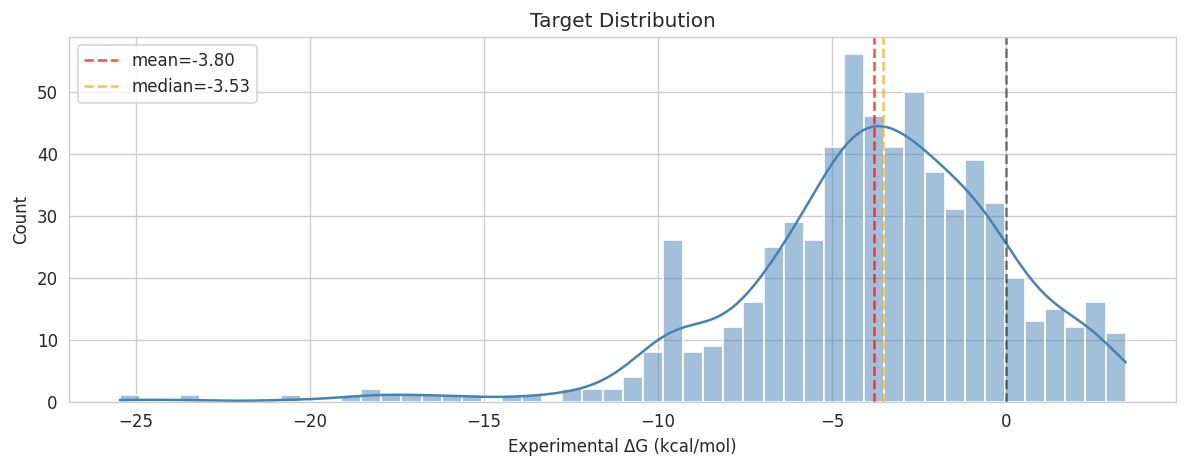

Mean: -3.80, Median: -3.53, Std: 3.85
Range: [-25.47, 3.43], Skew: -1.18
Positive ΔG (hydrophobic): 84 (13.1%)


In [12]:
# Target distribution
fig, ax = plt.subplots(figsize=(10, 4))

sns.histplot(df["expt"], bins=50, kde=True, ax=ax, color="steelblue")
ax.axvline(0, color="black", linestyle="--", alpha=0.5)
ax.axvline(df["expt"].mean(), color="red", linestyle="--", alpha=0.7, label=f"mean={df['expt'].mean():.2f}")
ax.axvline(df["expt"].median(), color="orange", linestyle="--", alpha=0.7, label=f"median={df['expt'].median():.2f}")
ax.set_xlabel("Experimental ΔG (kcal/mol)")
ax.set_title("Target Distribution")
ax.legend()

plt.tight_layout()
plt.show()

print(f"Mean: {df['expt'].mean():.2f}, Median: {df['expt'].median():.2f}, Std: {df['expt'].std():.2f}")
print(f"Range: [{df['expt'].min():.2f}, {df['expt'].max():.2f}], Skew: {df['expt'].skew():.2f}")
print(f"Positive ΔG (hydrophobic): {(df['expt'] > 0).sum()} ({(df['expt'] > 0).mean()*100:.1f}%)")

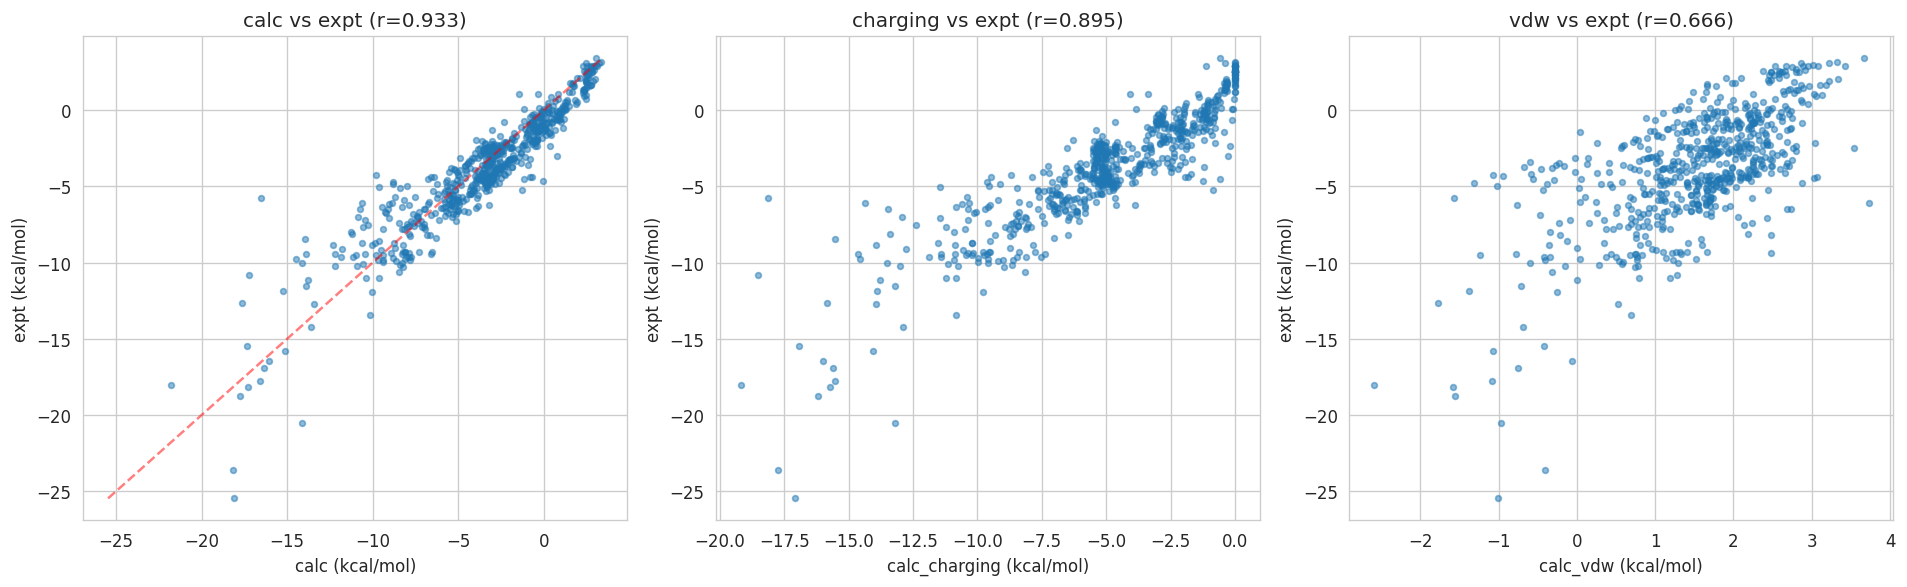

calc vs (charging + vdw) — max residual: 0.001000


In [13]:
# calc vs expt (should correlate strongly), and decomposition: calc ≈ calc_charging + calc_vdw
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].scatter(df["calc"], df["expt"], s=12, alpha=0.5)
lims = [min(df["expt"].min(), df["calc"].min()), max(df["expt"].max(), df["calc"].max())]
axes[0].plot(lims, lims, "r--", alpha=0.5)
axes[0].set_xlabel("calc (kcal/mol)"); axes[0].set_ylabel("expt (kcal/mol)")
axes[0].set_title(f"calc vs expt (r={df['calc'].corr(df['expt']):.3f})")

axes[1].scatter(df["calc_charging"], df["expt"], s=12, alpha=0.5)
axes[1].set_xlabel("calc_charging (kcal/mol)"); axes[1].set_ylabel("expt (kcal/mol)")
axes[1].set_title(f"charging vs expt (r={df['calc_charging'].corr(df['expt']):.3f})")

axes[2].scatter(df["calc_vdw"], df["expt"], s=12, alpha=0.5)
axes[2].set_xlabel("calc_vdw (kcal/mol)"); axes[2].set_ylabel("expt (kcal/mol)")
axes[2].set_title(f"vdw vs expt (r={df['calc_vdw'].corr(df['expt']):.3f})")

plt.tight_layout()
plt.show()

residual = (df["calc"] - (df["calc_charging"] + df["calc_vdw"])).abs()
print(f"calc vs (charging + vdw) — max residual: {residual.max():.6f}")

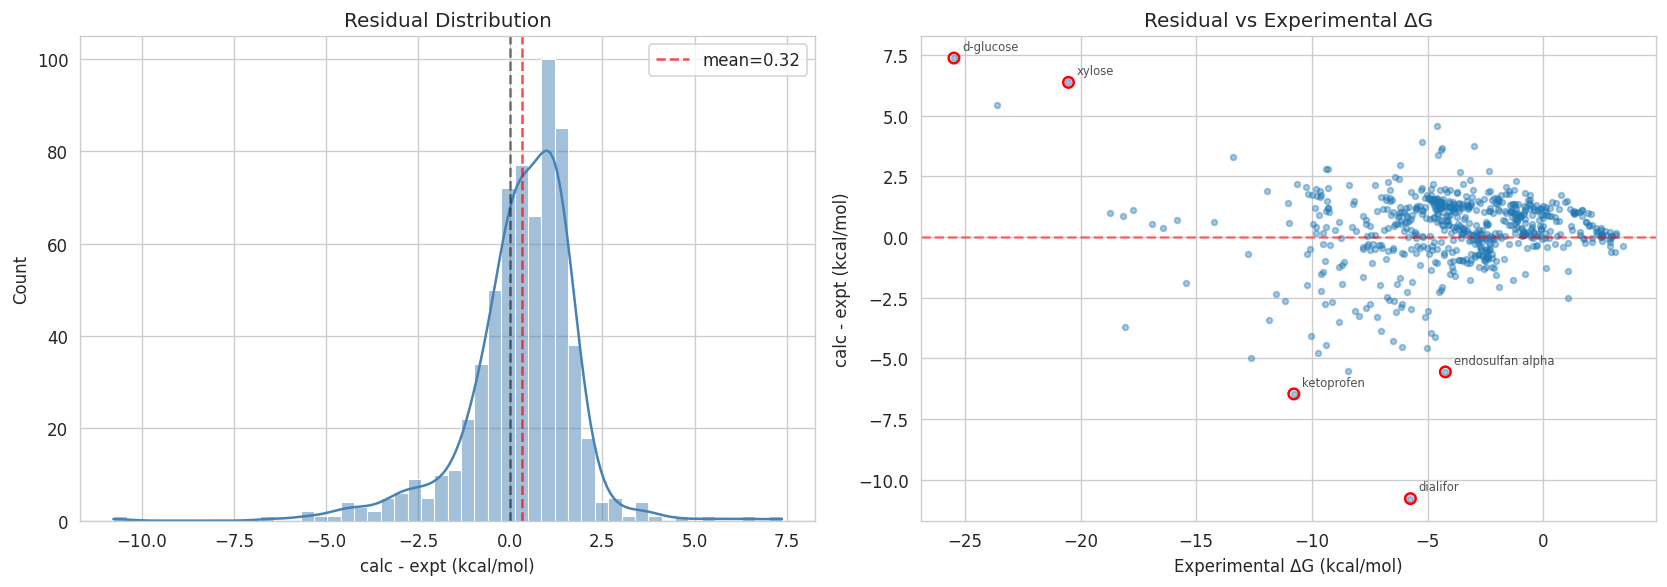

Mean residual: 0.32, Std: 1.51

Correlation with residual:
  calc_charging: 0.434
  calc_vdw:      0.075

Top 10 worst predictions:
                        nickname   expt    calc  residual
cid                                                      
mobley_2518989          dialifor  -5.74 -16.515   -10.775
mobley_9534740         d-glucose -25.47 -18.095     7.375
mobley_2099370        ketoprofen -10.78 -17.242    -6.462
mobley_1896013            xylose -20.52 -14.148     6.372
mobley_9571888  endosulfan alpha  -4.23  -9.785    -5.555
mobley_1527293      flurbiprofen  -8.42 -13.953    -5.533
mobley_4587267          mannitol -23.62 -18.162     5.458
mobley_7378987          caffeine -12.64 -17.621    -4.981
mobley_194273           bromacil  -9.73 -14.496    -4.766
mobley_7326706      chlorpyrifos  -5.04  -9.625    -4.585


In [14]:
df["residual"] = df["calc"] - df["expt"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["residual"], bins=50, kde=True, ax=axes[0], color="steelblue")
axes[0].axvline(0, color="black", linestyle="--", alpha=0.5)
axes[0].axvline(df["residual"].mean(), color="red", linestyle="--", alpha=0.7, label=f"mean={df['residual'].mean():.2f}")
axes[0].set_xlabel("calc - expt (kcal/mol)")
axes[0].set_title("Residual Distribution")
axes[0].legend()

axes[1].scatter(df["expt"], df["residual"], s=12, alpha=0.4)
axes[1].axhline(0, color="red", linestyle="--", alpha=0.5)
worst5_idx = df["residual"].abs().nlargest(5).index
for idx in worst5_idx:
    row = df.loc[idx]
    name = row["nickname"].strip() if len(row["nickname"].strip()) < 20 else row["iupac"][:20]
    axes[1].annotate(name, (row["expt"], row["residual"]),
                     fontsize=7, alpha=0.8, textcoords="offset points", xytext=(5, 5))
axes[1].scatter(df.loc[worst5_idx, "expt"], df.loc[worst5_idx, "residual"],
                s=40, facecolors="none", edgecolors="red", linewidths=1.5)
axes[1].set_xlabel("Experimental ΔG (kcal/mol)")
axes[1].set_ylabel("calc - expt (kcal/mol)")
axes[1].set_title("Residual vs Experimental ΔG")

plt.tight_layout()
plt.show()

print(f"Mean residual: {df['residual'].mean():.2f}, Std: {df['residual'].std():.2f}")

# Which energy component correlates more with the error?
print(f"\nCorrelation with residual:")
print(f"  calc_charging: {df['calc_charging'].corr(df['residual']):.3f}")
print(f"  calc_vdw:      {df['calc_vdw'].corr(df['residual']):.3f}")

worst10_idx = df["residual"].abs().nlargest(10).index
worst = df.loc[worst10_idx, ["nickname", "expt", "calc", "residual"]].copy()
worst["nickname"] = worst["nickname"].str.strip()
print(f"\nTop 10 worst predictions:")
print(worst.to_string())

Slight positive bias (mean +0.32 kcal/mol). For context: under 1 kcal/mol error is generally acceptable, 1–4 kcal/mol is poor, and above 4 kcal/mol is a serious miss. Most molecules fall in the acceptable range, but the 10 worst are all above 4.5 kcal/mol — polyols (glucose, xylose, mannitol), drugs (ketoprofen, flurbiprofen, caffeine), and organophosphates (dialifor, chlorpyrifos).

`calc_charging` correlates 0.43 with the residual, `calc_vdw` is near zero (0.08). But charging is also the dominant component of `calc` overall, so this doesn't tell us whether the electrostatic calculation is actually *causing* the error — we'd need ground-truth decomposition of the experimental ΔG to check that, and we don't have it.

## Molecular Descriptors

The energy columns above are simulation outputs — they don't describe molecular structure directly. RDKit 2D descriptors give us structural features (size, polarity, H-bonding, etc.) that we can check against hydration free energy.

In [15]:
mols = df["smiles"].apply(Chem.MolFromSmiles)
failed = mols.isna().sum()
print(f"Failed to parse: {failed}/{len(df)}")

desc_funcs = {
    "MolWt": Descriptors.MolWt,
    "LogP": Descriptors.MolLogP,
    "HBA": Descriptors.NumHAcceptors,
    "HBD": Descriptors.NumHDonors,
    "TPSA": Descriptors.TPSA,
    "RotBonds": Descriptors.NumRotatableBonds,
    "RingCount": Descriptors.RingCount,
    "AromaticRings": Descriptors.NumAromaticRings,
    "HeavyAtoms": Descriptors.HeavyAtomCount,
    "FractionCSP3": Descriptors.FractionCSP3,
    "NumHeteroatoms": Descriptors.NumHeteroatoms,
}

for name, func in desc_funcs.items():
    df[name] = mols.apply(func)

df[list(desc_funcs.keys())].describe().round(2)

Failed to parse: 0/642


,MolWt,LogP,HBA,HBD,TPSA,RotBonds,RingCount,AromaticRings,HeavyAtoms,FractionCSP3,NumHeteroatoms
count,642.00,642.00,642.00,642.00,642.00,642.00,642.00,642.00,642.00,642.00,642.00
mean,138.95,1.93,1.29,0.34,20.40,1.63,0.67,0.52,8.72,0.57,2.21
std,72.70,1.49,1.42,0.63,22.64,1.97,0.81,0.69,4.19,0.40,2.17
min,16.04,-3.59,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00
25%,94.12,1.16,0.00,0.00,0.00,0.00,0.00,0.00,6.00,0.14,1.00
50%,120.88,1.78,1.00,0.00,17.07,1.00,1.00,0.00,8.00,0.67,2.00
75%,159.70,2.58,2.00,1.00,26.30,3.00,1.00,1.00,10.00,1.00,3.00
max,498.66,9.89,8.00,6.00,123.66,12.00,5.00,4.00,24.00,1.00,11.00


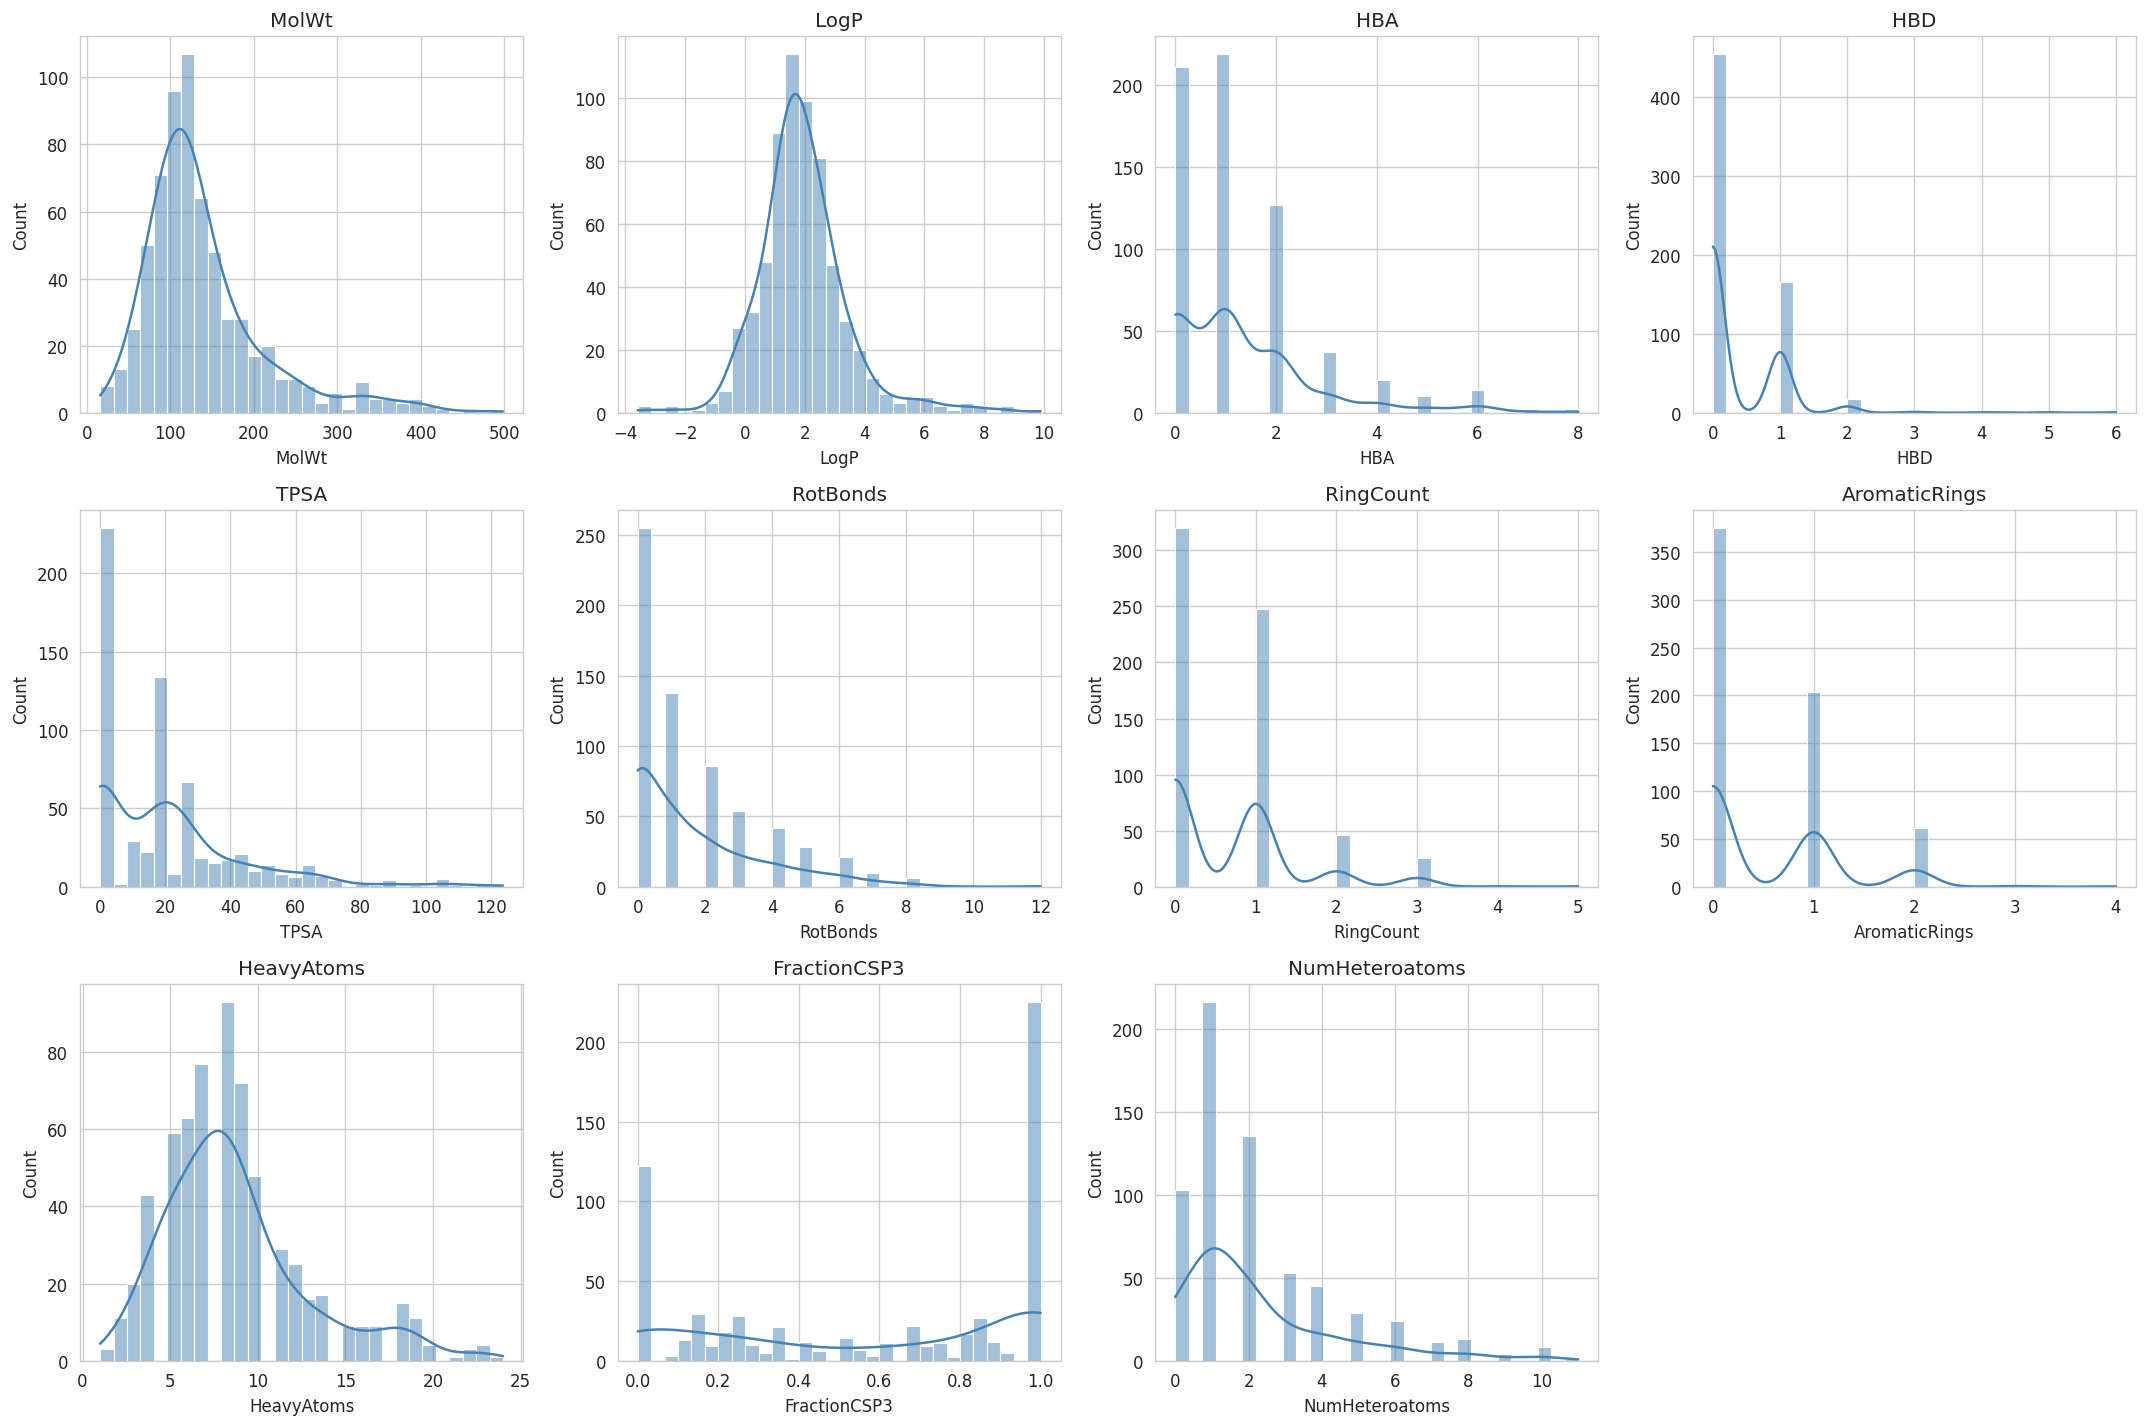

In [16]:
desc_cols = list(desc_funcs.keys())
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(desc_cols):
    sns.histplot(df[col], bins=30, kde=True, ax=axes[i], color="steelblue")
    axes[i].set_title(col)

axes[-1].set_visible(False)
plt.tight_layout()
plt.show()

Most molecules are small (MolWt < 200, median 121). FractionCSP3 is bimodal — either fully saturated or fully aromatic. HBD and HBA are mostly zero (many molecules have no hydrogen bond capacity at all).

In [17]:
# Now that we have descriptors — how do the worst-predicted molecules compare?
worst10_idx = df["residual"].abs().nlargest(10).index

compare = pd.DataFrame({
    "worst_10": df.loc[worst10_idx, desc_cols].mean(),
    "rest": df.loc[~df.index.isin(worst10_idx), desc_cols].mean(),
})
compare["diff"] = compare["worst_10"] - compare["rest"]
print("Descriptor comparison (mean) — worst 10 vs rest:")
print(compare.round(2).to_string())

Descriptor comparison (mean) — worst 10 vs rest:
                worst_10    rest    diff
MolWt             261.77  137.01  124.76
LogP                1.02    1.95   -0.92
HBA                 3.90    1.25    2.65
HBD                 1.80    0.32    1.48
TPSA               66.22   19.68   46.54
RotBonds            2.90    1.61    1.29
RingCount           1.50    0.65    0.85
AromaticRings       0.90    0.52    0.38
HeavyAtoms         15.90    8.61    7.29
FractionCSP3        0.58    0.57    0.02
NumHeteroatoms      6.20    2.15    4.05


The worst-predicted molecules are bigger (MolWt 262 vs 137), more polar (TPSA 66 vs 20), and have more H-bond donors/acceptors. Mostly polyols, complex drugs, and organophosphates.

## Correlations

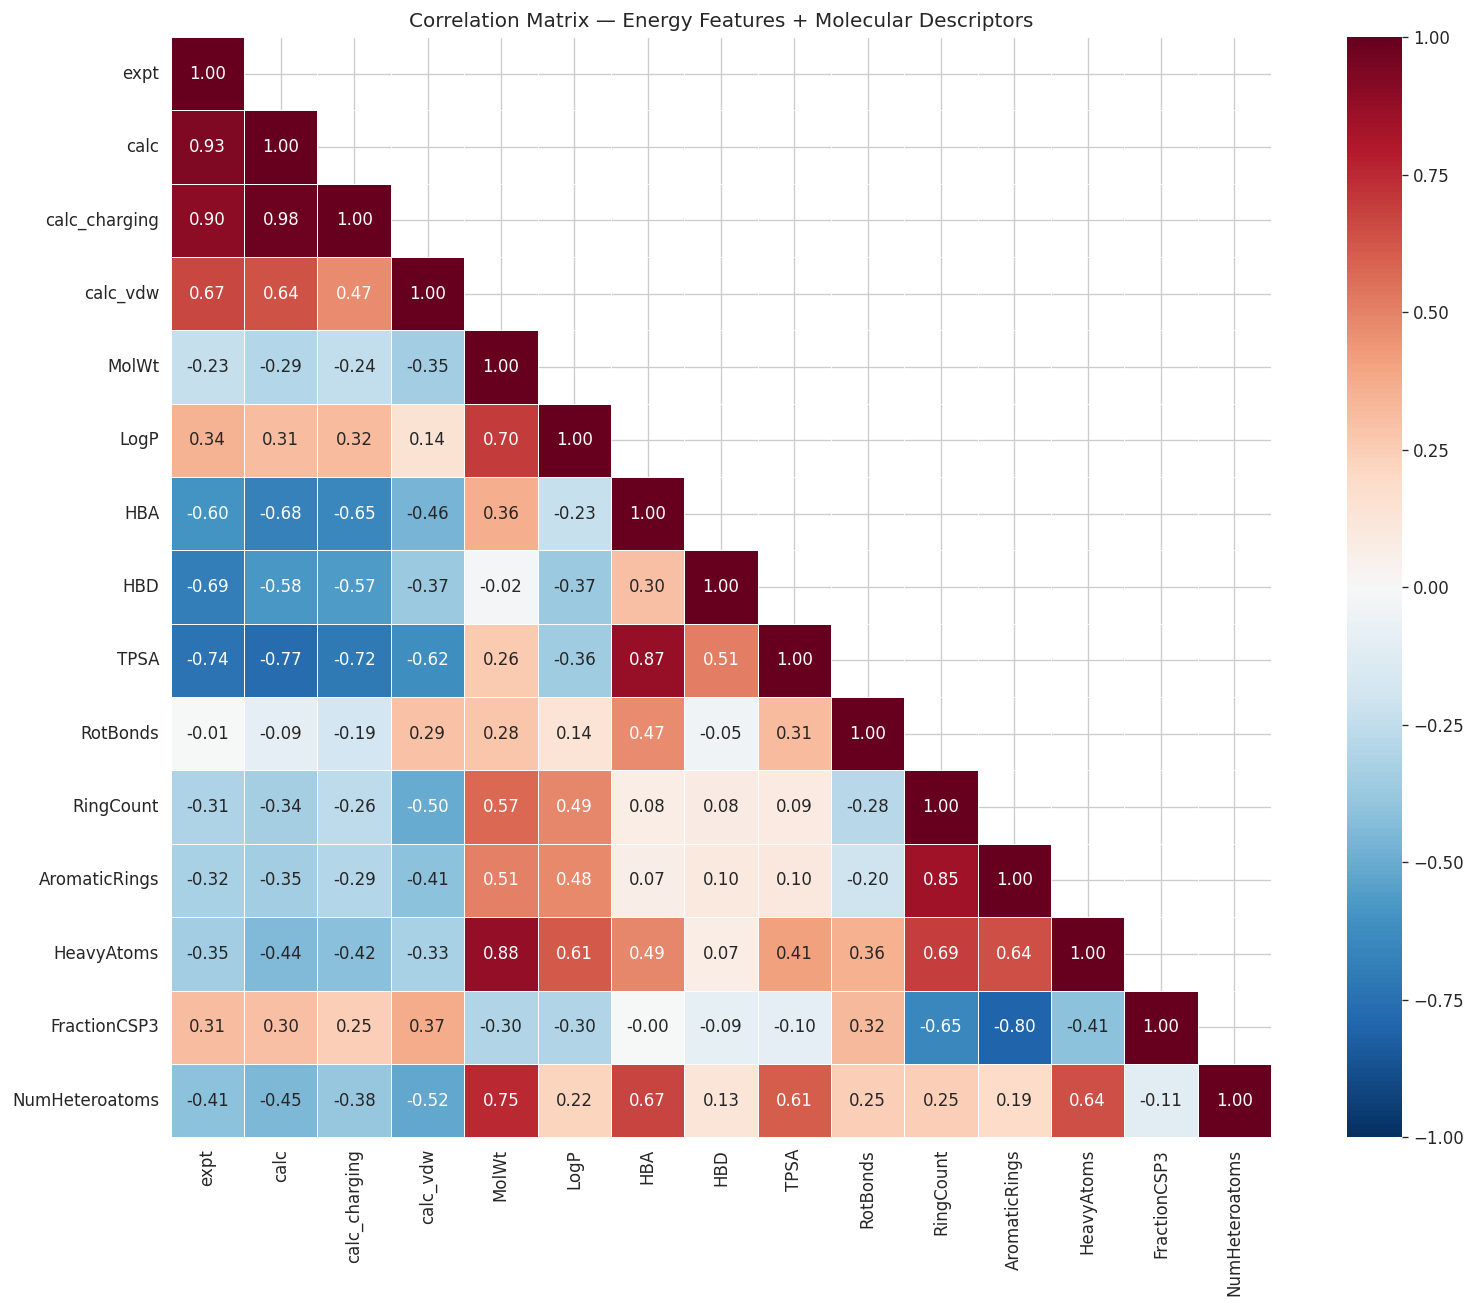

In [18]:
corr_cols = ["expt", "calc", "calc_charging", "calc_vdw"] + desc_cols
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, square=True, ax=ax, linewidths=0.5)
ax.set_title("Correlation Matrix — Energy Features + Molecular Descriptors")
plt.tight_layout()
plt.show()

LogP — the standard measure of how hydrophobic a molecule is — only correlates 0.34 with experimental ΔG. TPSA dominates at -0.74. So the solvation free energy depends more on specific polar interactions (hydrogen bonds, electrostatics) than on bulk hydrophobicity.

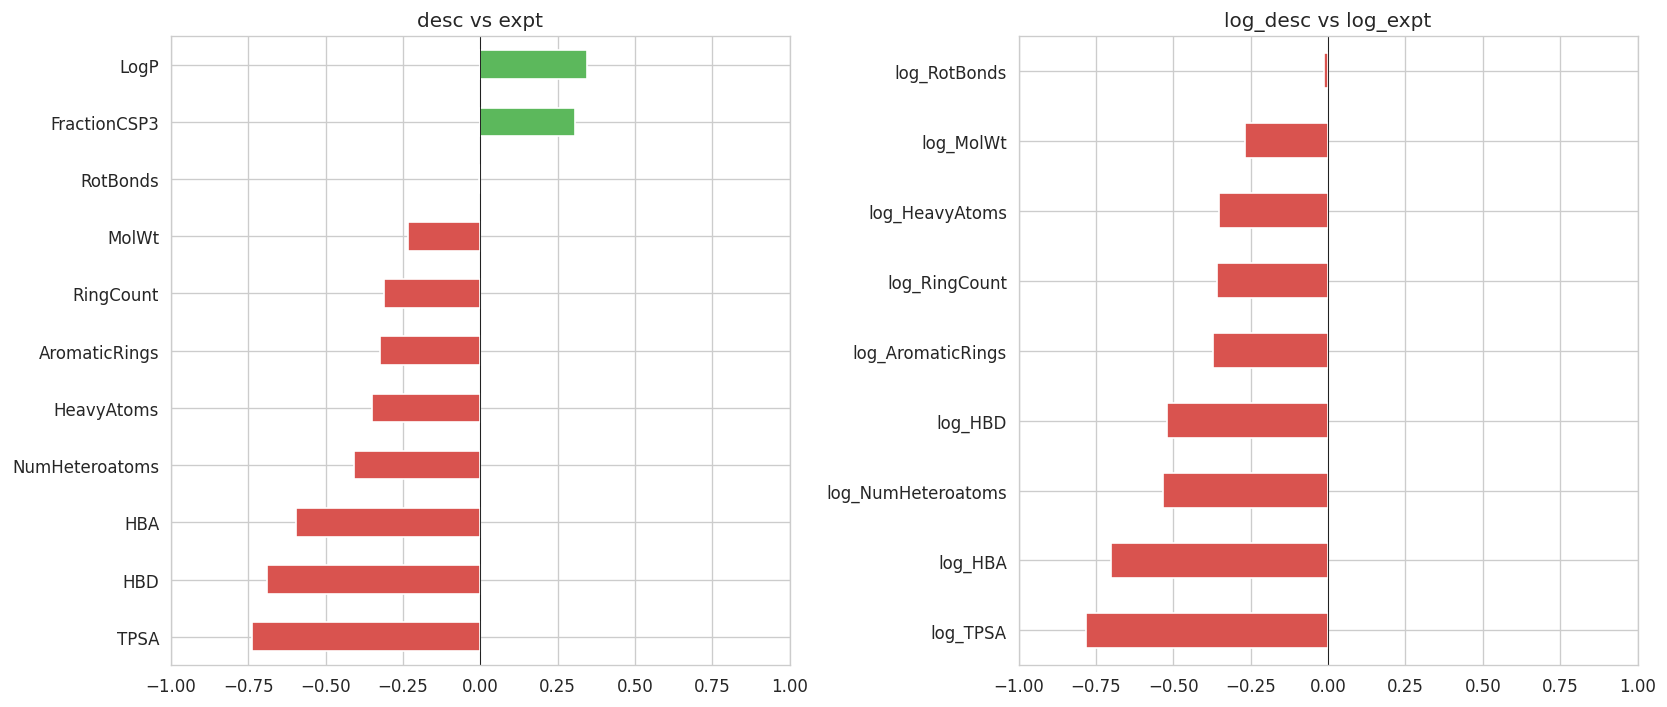

In [19]:
def signed_log1p(x):
    return np.sign(x) * np.log1p(np.abs(x))

# Descriptors suitable for log transform (non-negative, wide range)
log_desc_cols = ["MolWt", "HBA", "HBD", "TPSA", "RotBonds", "RingCount",
                 "AromaticRings", "HeavyAtoms", "NumHeteroatoms"]
# Skip FractionCSP3 (0-1 bounded) and LogP (already log-scale)

log_desc = df[log_desc_cols].apply(np.log1p)
log_desc.columns = [f"log_{c}" for c in log_desc_cols]

log_target = signed_log1p(df["expt"])
log_target.name = "log_expt"

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

corrs_raw = df[desc_cols].corrwith(df["expt"]).sort_values()
corrs_raw.plot.barh(ax=axes[0], color=["#d9534f" if v < 0 else "#5cb85c" for v in corrs_raw])
axes[0].set_title("desc vs expt")
axes[0].set_xlim(-1, 1)
axes[0].axvline(0, color="black", linewidth=0.5)

corrs_log = log_desc.corrwith(log_target).sort_values()
corrs_log.plot.barh(ax=axes[1], color=["#d9534f" if v < 0 else "#5cb85c" for v in corrs_log])
axes[1].set_title("log_desc vs log_expt")
axes[1].set_xlim(-1, 1)
axes[1].axvline(0, color="black", linewidth=0.5)

plt.tight_layout()
plt.show()

Log transforms don't really change the picture — the strongest predictors (TPSA, HBD, HBA) stay on top in both variants. The relationships are already close to linear.

Top correlated with expt:
TPSA              0.736
HBD               0.690
HBA               0.597
NumHeteroatoms    0.408
HeavyAtoms        0.350
LogP              0.344
dtype: float64


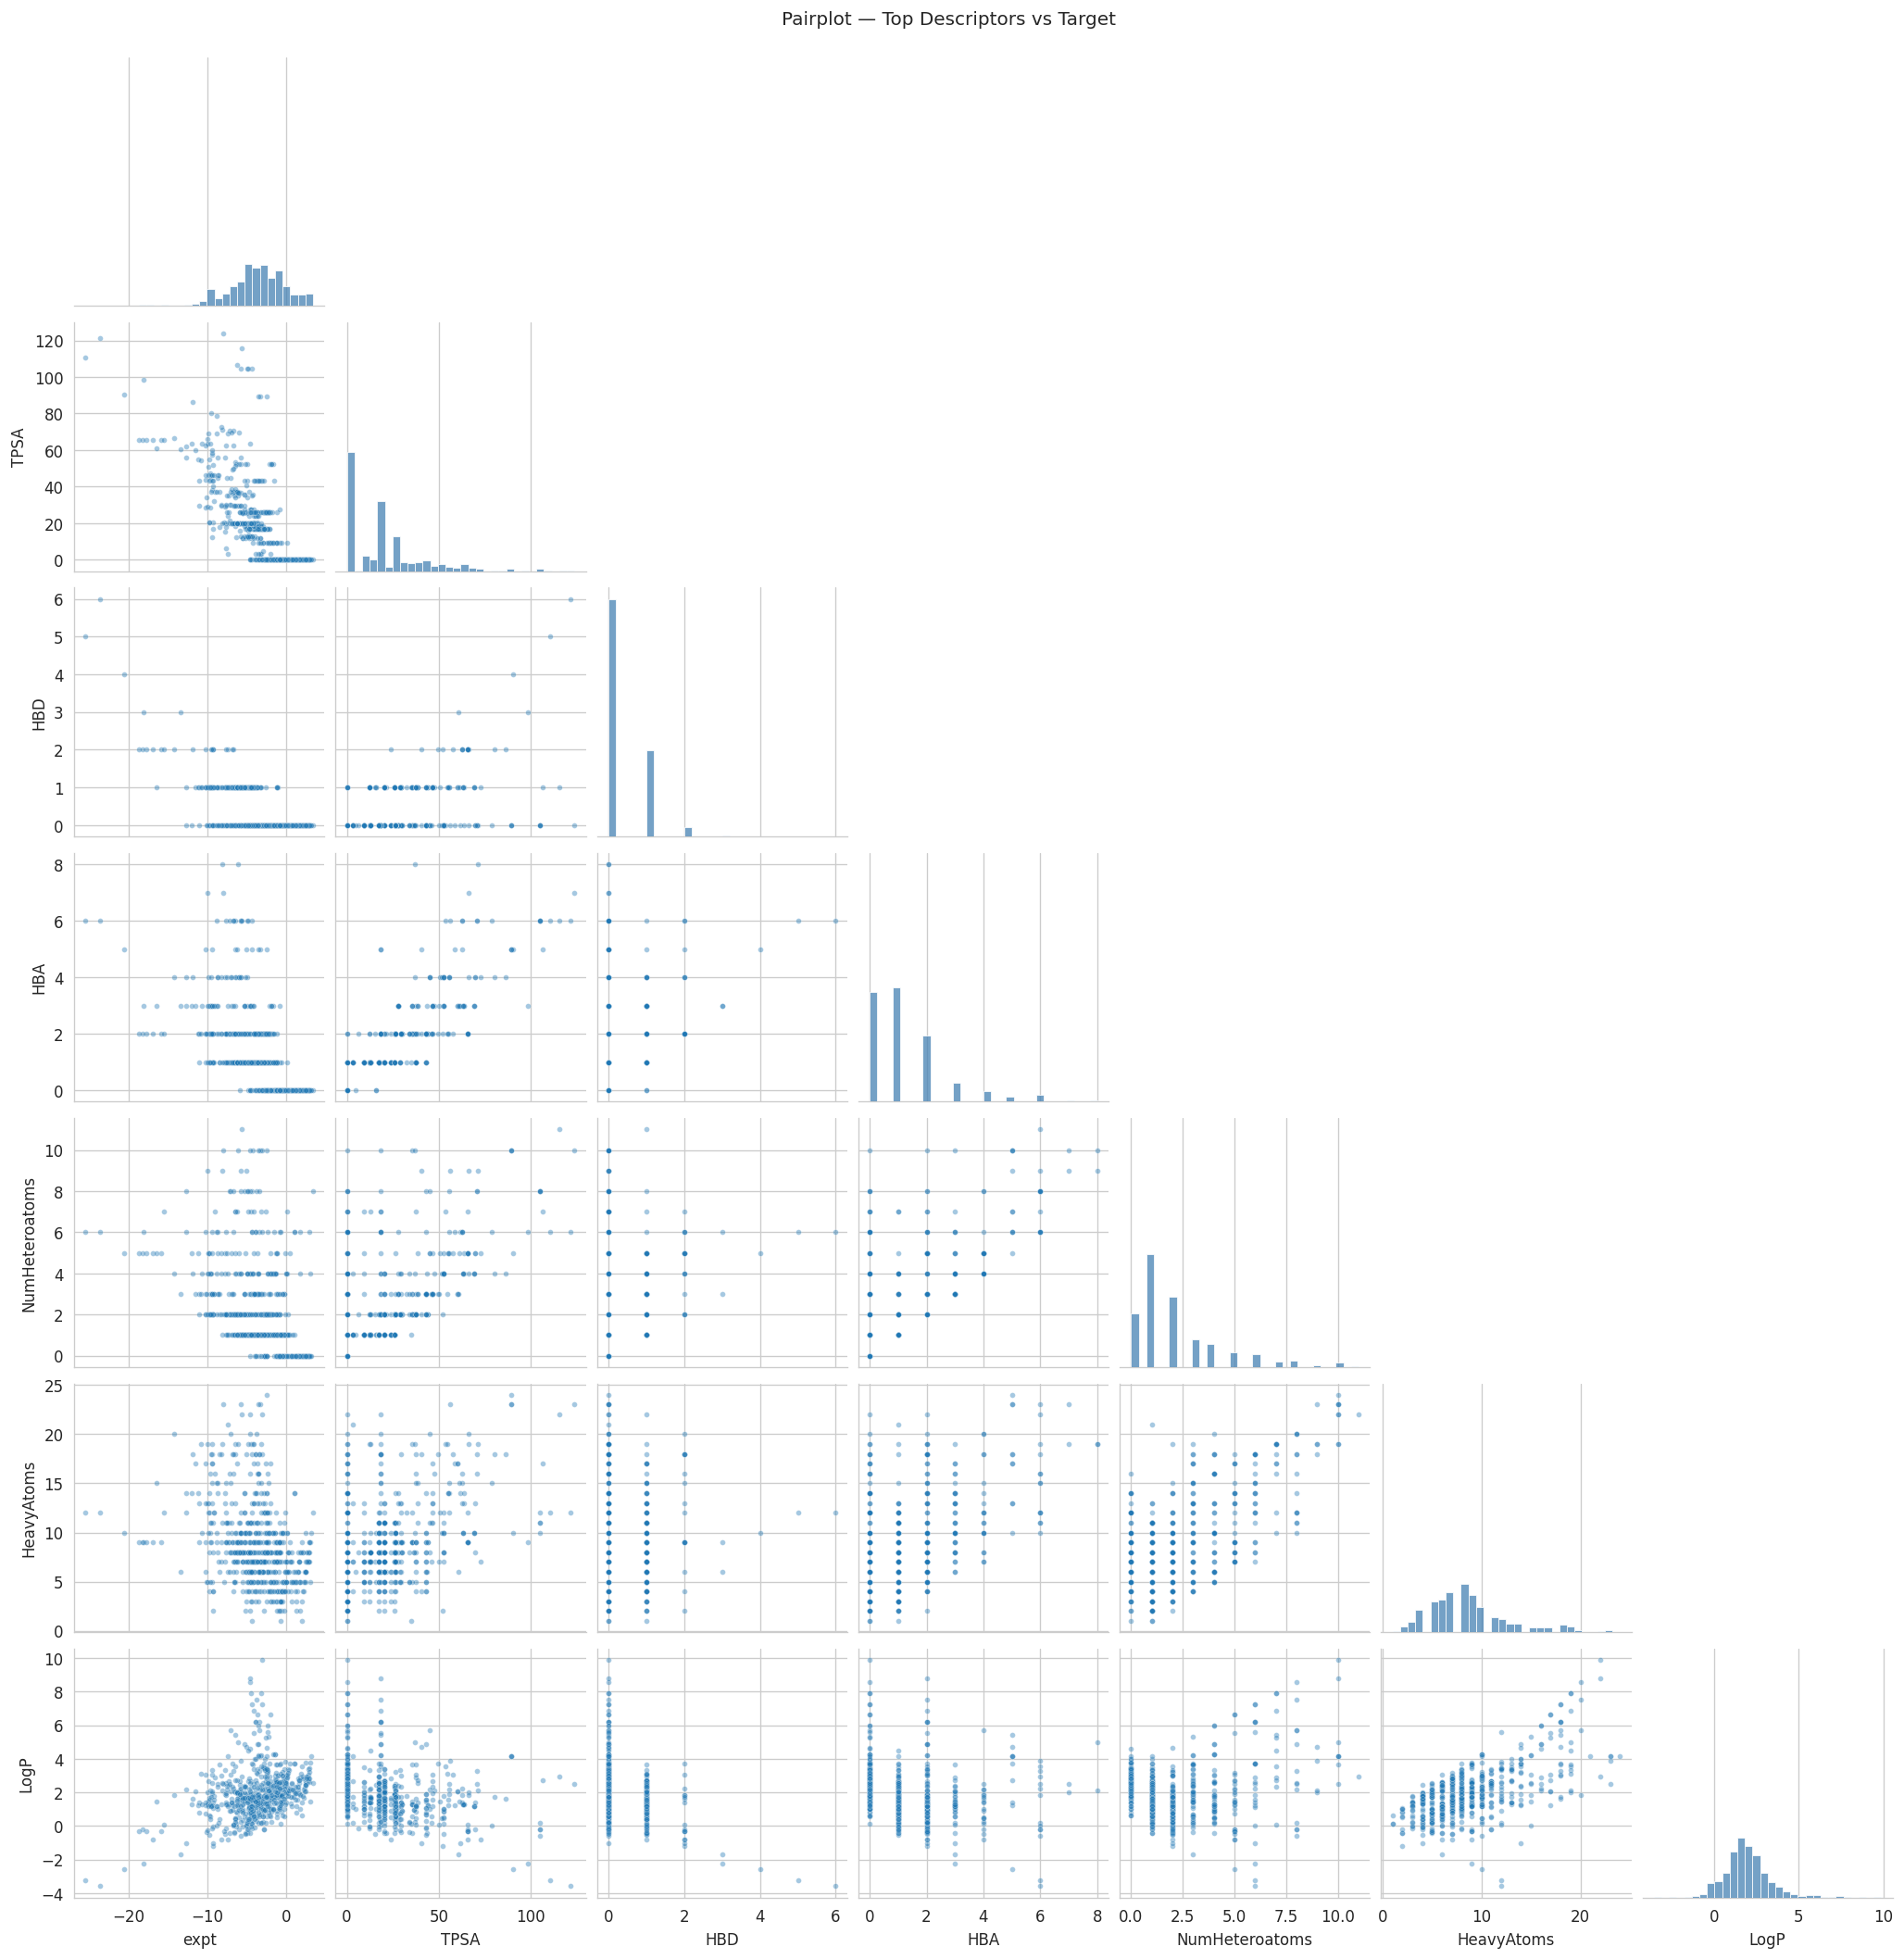

In [20]:
# Top 6 descriptors most correlated with expt (by absolute value)
top_corr = df[desc_cols].corrwith(df["expt"]).abs().nlargest(6)
print("Top correlated with expt:")
print(top_corr.round(3))

pair_cols = ["expt"] + top_corr.index.tolist()
g = sns.pairplot(df[pair_cols], corner=True, plot_kws={"s": 12, "alpha": 0.4},
                 diag_kws={"bins": 30, "color": "steelblue"})
g.figure.suptitle("Pairplot — Top Descriptors vs Target", y=1.01)
plt.show()

## Functional Groups Analysis

In [21]:
# Groups is multi-label — a molecule can be e.g. ("aromatic", "halogen derivative") — so we
# unpack each label into its own row to get per-group stats
df_groups = df[["expt", "groups"]].explode("groups")
df_groups = df_groups[df_groups["groups"] != ""]

group_stats = df_groups.groupby("groups")["expt"].agg(["count", "mean", "median", "std"]).sort_values("count", ascending=False)
print(f"Total unique groups: {len(group_stats)}")
print(f"Molecules with no group label: {(df['groups'].apply(len) == 0).sum()}")
print()
group_stats.round(2)

Total unique groups: 72
Molecules with no group label: 0



,count,mean,median,std
groups,,,,
aromatic,267,-5.45,-4.93,3.63
heterocyclic,88,-7.26,-5.50,4.67
aryl chloride,61,-4.85,-4.01,3.63
carboxylic acid ester,52,-4.01,-2.78,2.43
alkene,50,-1.56,-0.88,2.98
...,...,...,...,...
sulfonyl halide,1,-4.87,-4.87,NaN
sulfoxide,1,-9.28,-9.28,NaN
sulfuric acid diester,1,-5.10,-5.10,NaN


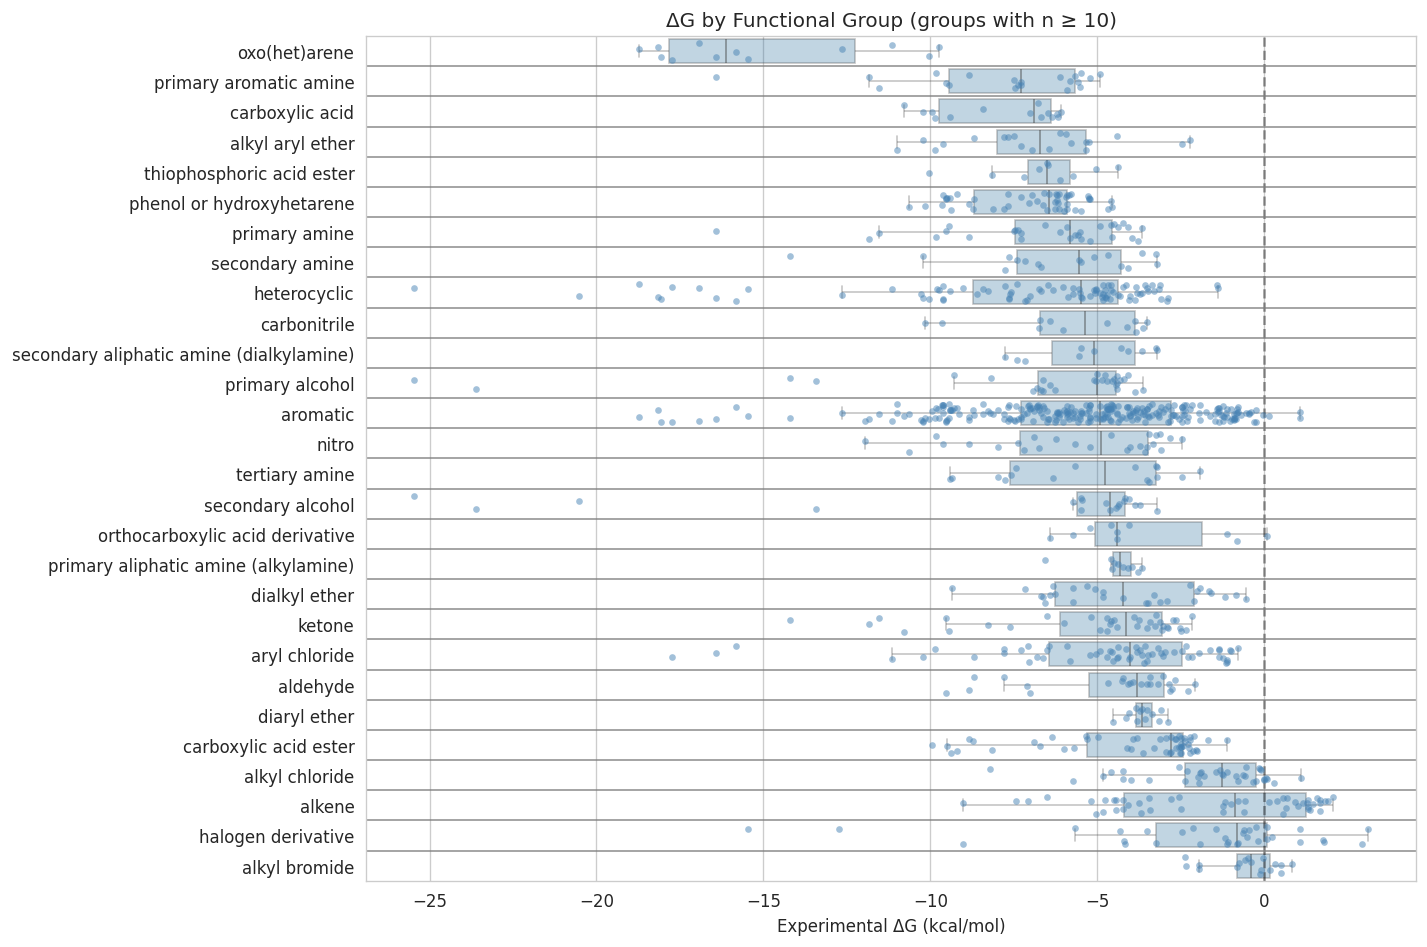

Showing 28 / 72 groups


In [22]:
min_count = 10
big_groups = group_stats[group_stats["count"] >= min_count].index.tolist()
df_plot = df_groups[df_groups["groups"].isin(big_groups)]

order = df_plot.groupby("groups")["expt"].median().sort_values().index

fig, ax = plt.subplots(figsize=(12, 8))
sns.boxplot(data=df_plot, y="groups", x="expt", order=order, ax=ax,
            showfliers=False, boxprops=dict(alpha=0.3), whiskerprops=dict(alpha=0.3),
            medianprops=dict(alpha=0.5), capprops=dict(alpha=0.3))
sns.stripplot(data=df_plot, y="groups", x="expt", order=order, ax=ax,
              size=4, alpha=0.5, jitter=0.3, color="steelblue")
ax.axvline(0, color="black", linestyle="--", alpha=0.4)
for i in range(len(order) - 1):
    ax.axhline(i + 0.5, color="grey", linewidth=1.2, alpha=0.7)
ax.set_xlabel("Experimental ΔG (kcal/mol)")
ax.set_ylabel("")
ax.set_title(f"ΔG by Functional Group (groups with n ≥ {min_count})")
plt.tight_layout()
plt.show()

print(f"Showing {len(big_groups)} / {len(group_stats)} groups")

In [23]:
# Group combos — using the full tuple label per molecule
combo_stats = df.groupby("groups")["expt"].agg(["count", "mean", "median", "std"]).sort_values("count", ascending=False)

# Clean up the empty-string tuple that shows as (,)
combo_stats.index = combo_stats.index.map(lambda g: ("no group",) if g == ("",) else g)
df["groups"] = df["groups"].apply(lambda g: ("no group",) if g == ("",) else g)

min_count = 8
big_combos = combo_stats[combo_stats["count"] >= min_count]
big_combos.round(2)

,count,mean,median,std
groups,,,,
no group,38,2.09,2.50,1.30
carboxylic acid ester,36,-3.07,-2.54,1.49
aromatic,35,-1.64,-0.90,1.31
aromatic,26,-5.22,-4.83,2.00
aromatic,25,-2.26,-2.16,1.18
alkene,23,1.11,1.31,0.69
alkyl chloride,21,-0.81,-0.63,0.94
ketone,20,-3.26,-3.08,0.78
aromatic,17,-6.19,-6.13,0.75


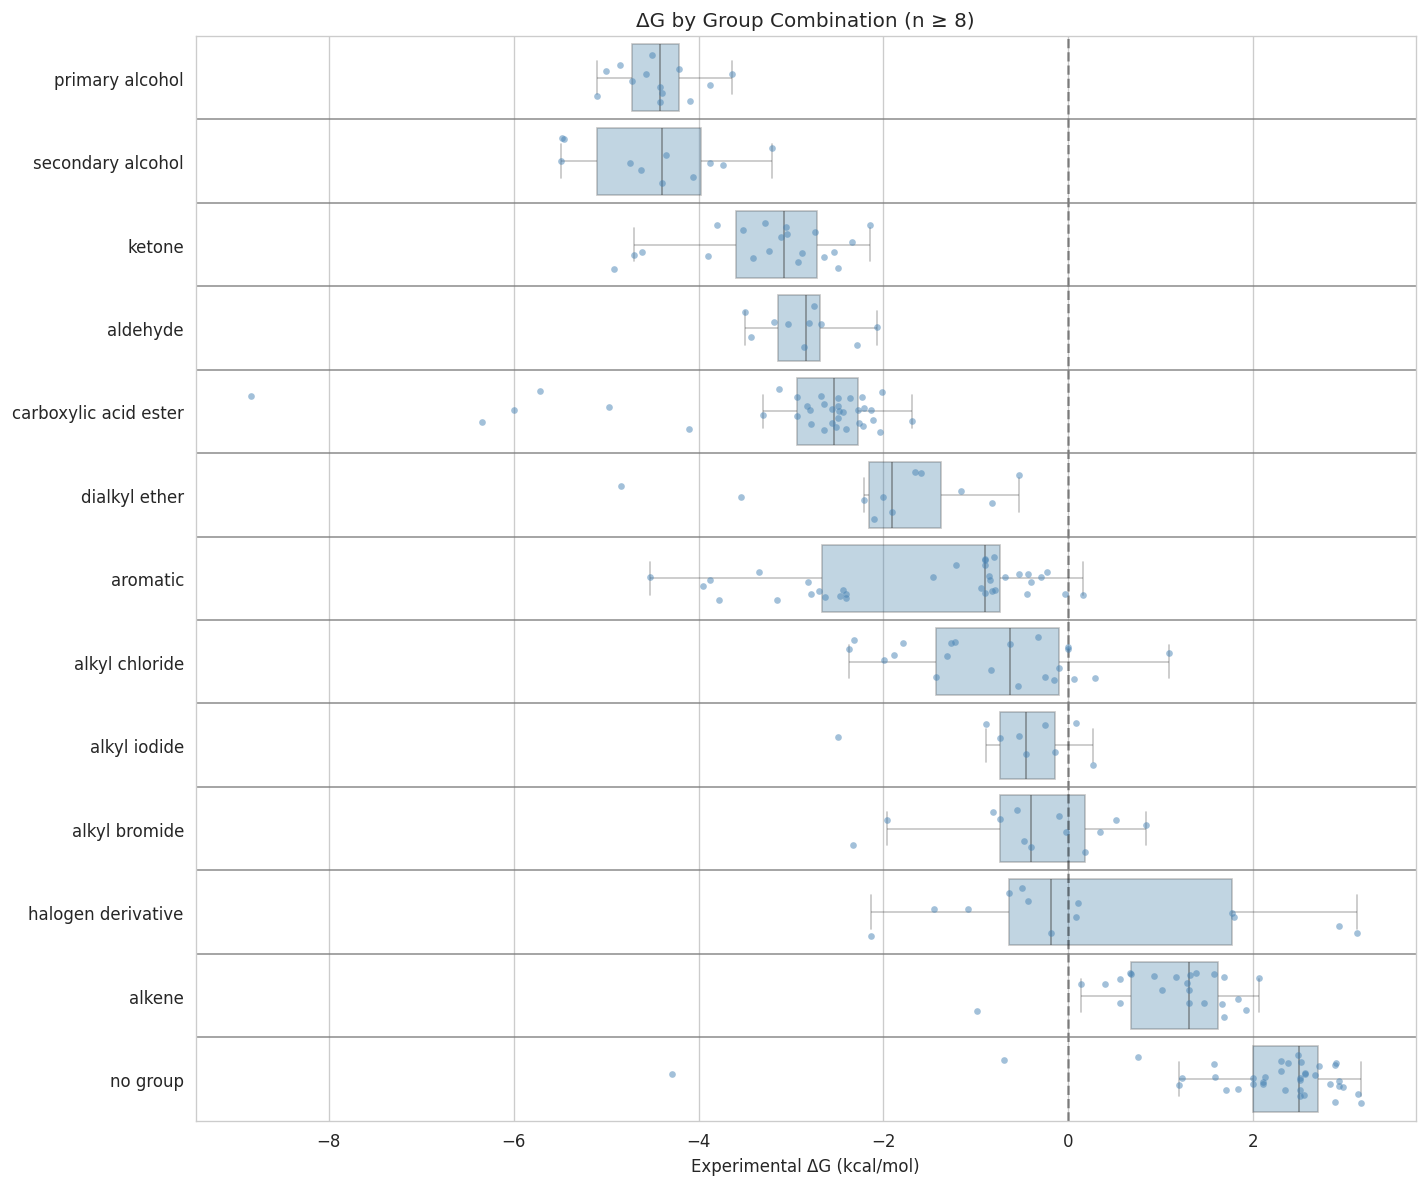

Showing 18 / 181 combos


In [24]:
big_combo_labels = big_combos.index.tolist()
df_combo_plot = df[df["groups"].isin(big_combo_labels)].copy()
df_combo_plot["group_label"] = df_combo_plot["groups"].apply(
    lambda g: " + ".join(g) if len(g) > 0 and any(g) else "no group"
)

order = df_combo_plot.groupby("group_label")["expt"].median().sort_values().index

fig, ax = plt.subplots(figsize=(12, 10))
sns.boxplot(data=df_combo_plot, y="group_label", x="expt", order=order, ax=ax,
            showfliers=False, boxprops=dict(alpha=0.3), whiskerprops=dict(alpha=0.3),
            medianprops=dict(alpha=0.5), capprops=dict(alpha=0.3))
sns.stripplot(data=df_combo_plot, y="group_label", x="expt", order=order, ax=ax,
              size=4, alpha=0.5, jitter=0.3, color="steelblue")
ax.axvline(0, color="black", linestyle="--", alpha=0.4)
for i in range(len(order) - 1):
    ax.axhline(i + 0.5, color="grey", linewidth=1.2, alpha=0.7)
ax.set_xlabel("Experimental ΔG (kcal/mol)")
ax.set_ylabel("")
ax.set_title(f"ΔG by Group Combination (n ≥ {min_count})")
plt.tight_layout()
plt.show()

print(f"Showing {len(big_combos)} / {len(combo_stats)} combos")

In [25]:
# Which functional groups does the simulation get wrong?
df_groups_resid = df[["residual", "groups"]].explode("groups")
df_groups_resid = df_groups_resid[df_groups_resid["groups"] != ""]
df_groups_resid["abs_residual"] = df_groups_resid["residual"].abs()

resid_stats = df_groups_resid.groupby("groups")["abs_residual"].agg(["count", "mean", "median", "std"]).sort_values("median", ascending=False)
min_count = 10
big = resid_stats[resid_stats["count"] >= min_count]
print(f"Groups with n ≥ {min_count}: {len(big)}")
print(big.round(2).to_string())

Groups with n ≥ 10: 29
                                          count  mean  median   std
groups                                                             
thiophosphoric acid ester                    10  3.96    3.68  2.71
carboxylic acid                              14  2.63    2.69  1.75
primary alcohol                              30  1.94    1.51  1.36
oxo(het)arene                                12  2.22    1.51  1.73
secondary alcohol                            19  2.12    1.44  2.03
nitro                                        26  1.48    1.44  0.99
dialkyl ether                                29  1.24    1.27  0.63
carbonitrile                                 12  1.12    1.26  0.53
alkyl chloride                               37  1.46    1.26  1.81
primary aliphatic amine (alkylamine)         10  1.18    1.25  0.25
secondary aliphatic amine (dialkylamine)     11  1.17    1.20  0.31
heterocyclic                                 88  1.71    1.17  1.74
secondary amine          

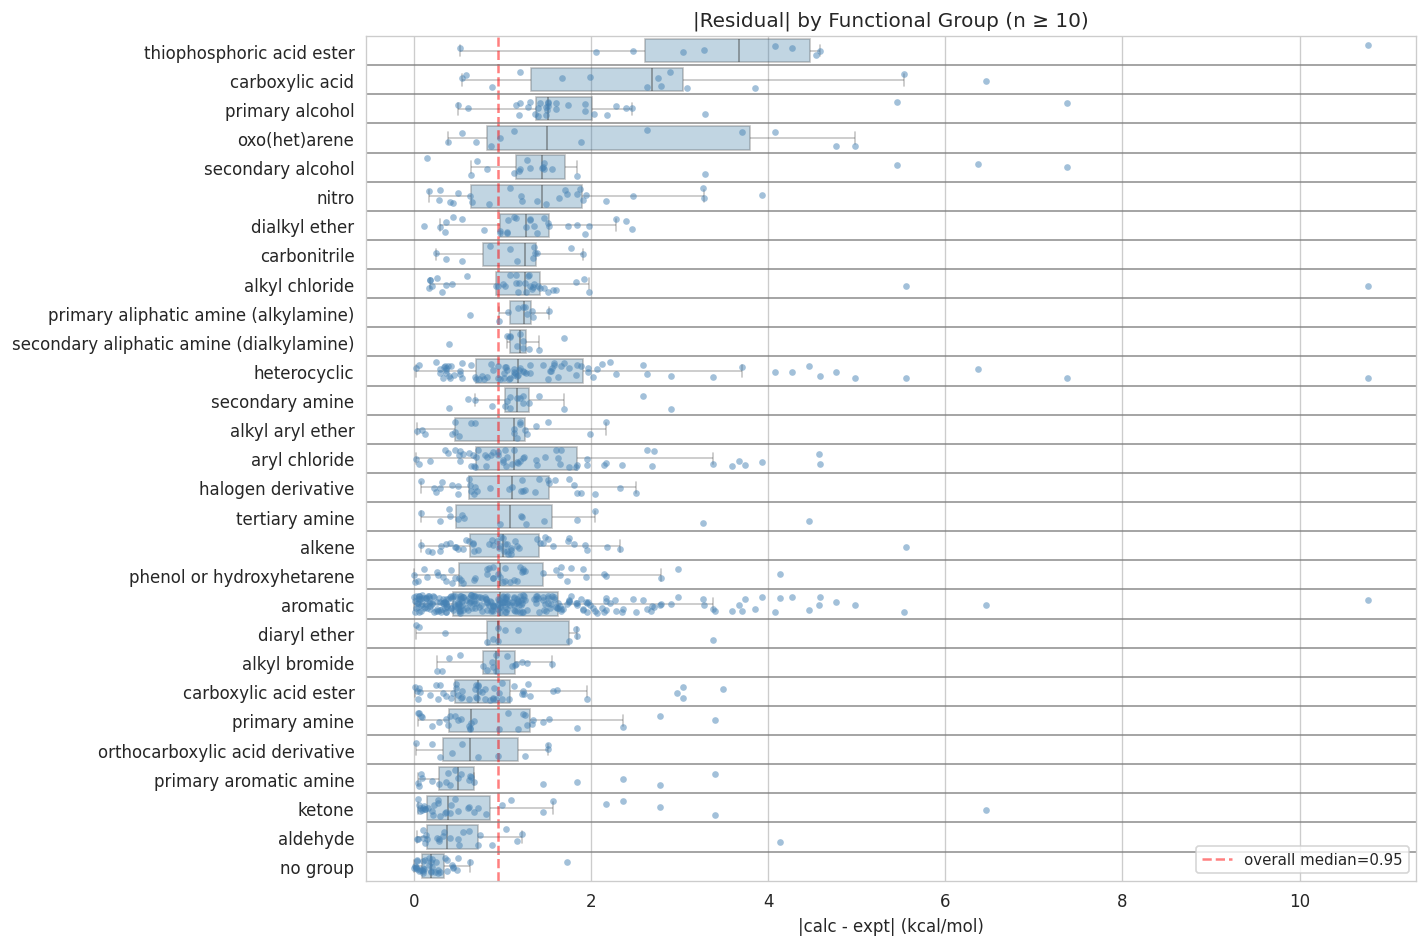

In [26]:
# Box+strip of |residual| by group
df_plot_resid = df_groups_resid[df_groups_resid["groups"].isin(big.index)]
order = df_plot_resid.groupby("groups")["abs_residual"].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(12, 8))
sns.boxplot(data=df_plot_resid, y="groups", x="abs_residual", order=order, ax=ax,
            showfliers=False, boxprops=dict(alpha=0.3), whiskerprops=dict(alpha=0.3),
            medianprops=dict(alpha=0.5), capprops=dict(alpha=0.3))
sns.stripplot(data=df_plot_resid, y="groups", x="abs_residual", order=order, ax=ax,
              size=4, alpha=0.5, jitter=0.3, color="steelblue")
ax.axvline(df["residual"].abs().median(), color="red", linestyle="--", alpha=0.5, label=f"overall median={df['residual'].abs().median():.2f}")
for i in range(len(order) - 1):
    ax.axhline(i + 0.5, color="grey", linewidth=1.2, alpha=0.7)
ax.set_xlabel("|calc - expt| (kcal/mol)")
ax.set_ylabel("")
ax.set_title(f"|Residual| by Functional Group (n ≥ {min_count})")
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()

In [27]:
# Same thing but for group combos
df["abs_residual"] = df["residual"].abs()
combo_resid = df.groupby("groups")["abs_residual"].agg(["count", "mean", "median", "std"]).sort_values("median", ascending=False)

min_count = 8
big_combos_resid = combo_resid[combo_resid["count"] >= min_count]
print(f"Combos with n ≥ {min_count}: {len(big_combos_resid)}")
print(big_combos_resid.round(2).to_string())

Combos with n ≥ 8: 18
                                                       count  mean  median   std
groups                                                                          
(primary alcohol,)                                        13  1.41    1.40  0.14
(aromatic, heterocyclic)                                  26  1.29    1.32  0.57
(secondary alcohol,)                                      11  1.21    1.31  0.41
(alkyl chloride,)                                         21  1.21    1.29  0.41
(primary aliphatic amine (alkylamine), primary amine)      9  1.14    1.24  0.23
(aromatic, aryl chloride)                                 25  1.70    1.11  1.19
(halogen derivative,)                                     13  0.91    1.07  0.49
(dialkyl ether,)                                          11  1.06    1.06  0.48
(alkene,)                                                 23  1.05    1.04  0.23
(aromatic, aryl chloride, diaryl ether, heterocyclic)     11  1.21    0.95  0.90
(alkyl

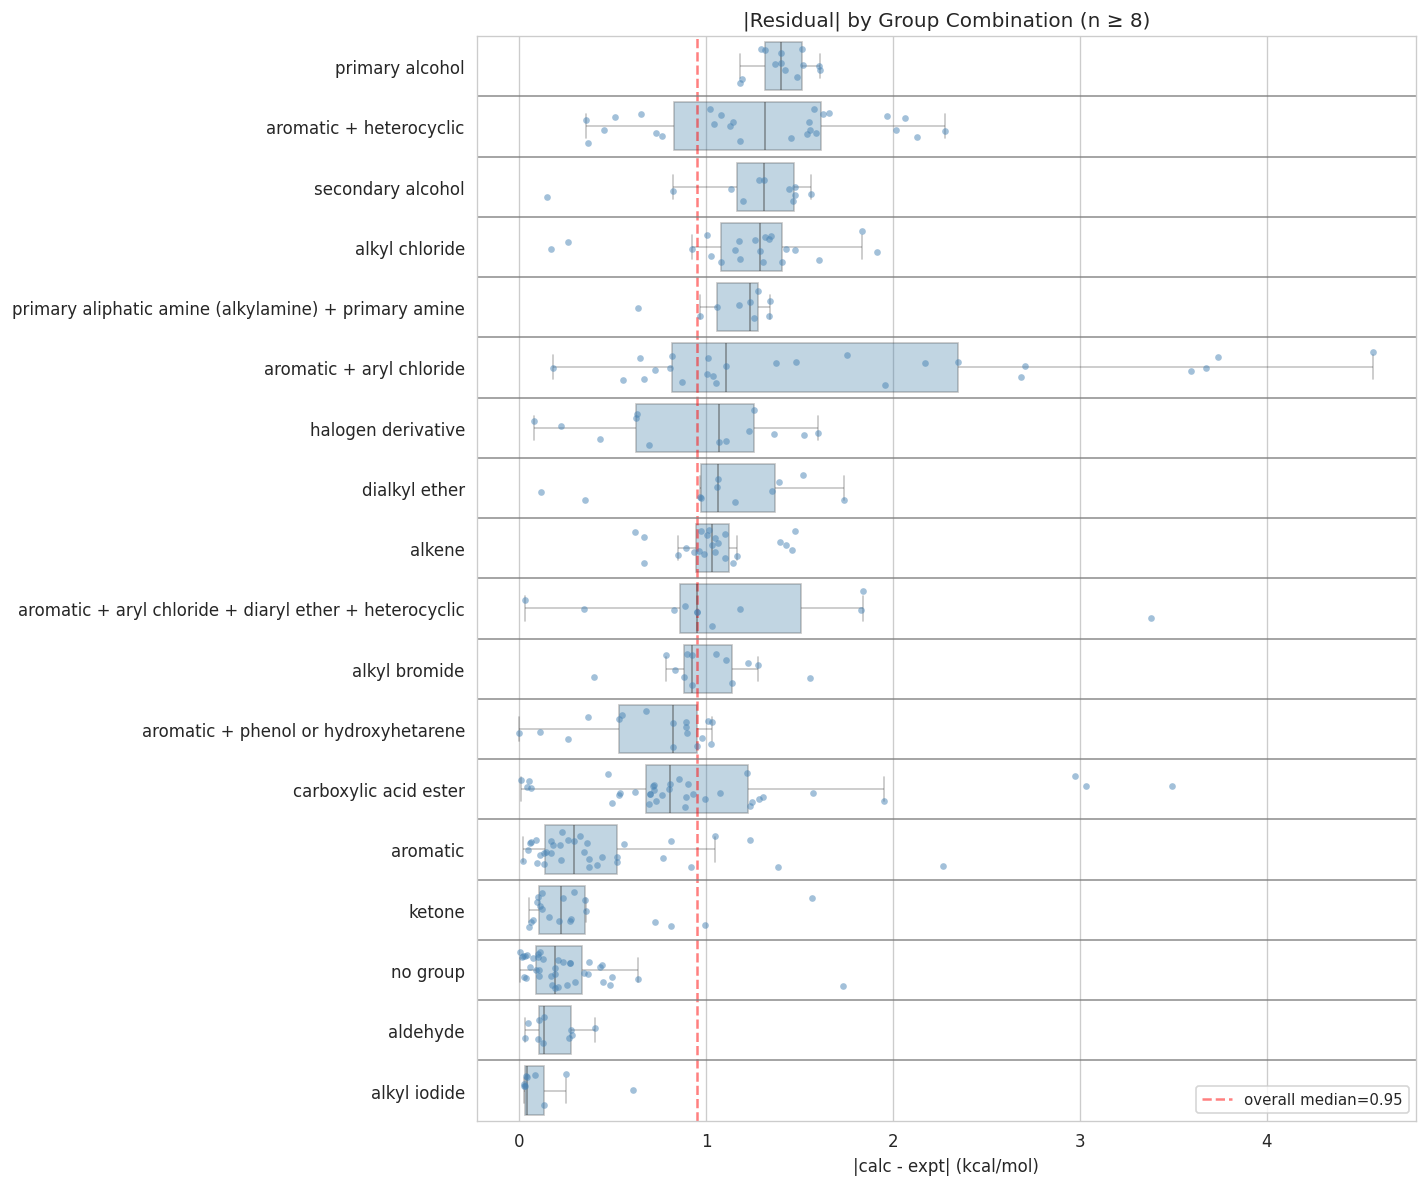

In [28]:
df_combo_resid_plot = df[df["groups"].isin(big_combos_resid.index)].copy()
df_combo_resid_plot["group_label"] = df_combo_resid_plot["groups"].apply(
    lambda g: " + ".join(g) if len(g) > 0 and any(g) else "no group"
)

order = df_combo_resid_plot.groupby("group_label")["abs_residual"].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(12, 10))
sns.boxplot(data=df_combo_resid_plot, y="group_label", x="abs_residual", order=order, ax=ax,
            showfliers=False, boxprops=dict(alpha=0.3), whiskerprops=dict(alpha=0.3),
            medianprops=dict(alpha=0.5), capprops=dict(alpha=0.3))
sns.stripplot(data=df_combo_resid_plot, y="group_label", x="abs_residual", order=order, ax=ax,
              size=4, alpha=0.5, jitter=0.3, color="steelblue")
ax.axvline(df["abs_residual"].median(), color="red", linestyle="--", alpha=0.5, label=f"overall median={df['abs_residual'].median():.2f}")
for i in range(len(order) - 1):
    ax.axhline(i + 0.5, color="grey", linewidth=1.2, alpha=0.7)
ax.set_xlabel("|calc - expt| (kcal/mol)")
ax.set_ylabel("")
ax.set_title(f"|Residual| by Group Combination (n ≥ {min_count})")
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()

## Chemical Space Visualization

In [29]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from rdkit.Chem import rdFingerprintGenerator

morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)
rdkit_gen = rdFingerprintGenerator.GetRDKitFPGenerator(fpSize=2048)

morgan_fps = np.array([morgan_gen.GetFingerprintAsNumPy(m) for m in mols])
rdkit_fps = np.array([rdkit_gen.GetFingerprintAsNumPy(m) for m in mols])

print(f"Morgan FPs: {morgan_fps.shape}")
print(f"RDKit FPs:  {rdkit_fps.shape}")

Morgan FPs: (642, 2048)
RDKit FPs:  (642, 2048)


In [30]:
import umap

# Compute all embeddings once
embeddings = {}
for fp_name, fps in [("Morgan", morgan_fps), ("RDKit", rdkit_fps)]:
    pca = PCA(n_components=2, random_state=42)
    embeddings[f"{fp_name}_PCA"] = pca.fit_transform(fps)
    embeddings[f"{fp_name}_PCA_var"] = pca.explained_variance_ratio_.sum()

    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    embeddings[f"{fp_name}_tSNE"] = tsne.fit_transform(fps)

    reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
    embeddings[f"{fp_name}_UMAP"] = reducer.fit_transform(fps)

print("Computed embeddings:")
for k, v in embeddings.items():
    if isinstance(v, np.ndarray):
        print(f"  {k}: {v.shape}")

/home/nginoyan/.conda/envs/nnp/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/nginoyan/.conda/envs/nnp/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/nginoyan/.conda/envs/nnp/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Computed embeddings:
  Morgan_PCA: (642, 2)
  Morgan_tSNE: (642, 2)
  Morgan_UMAP: (642, 2)
  RDKit_PCA: (642, 2)
  RDKit_tSNE: (642, 2)
  RDKit_UMAP: (642, 2)


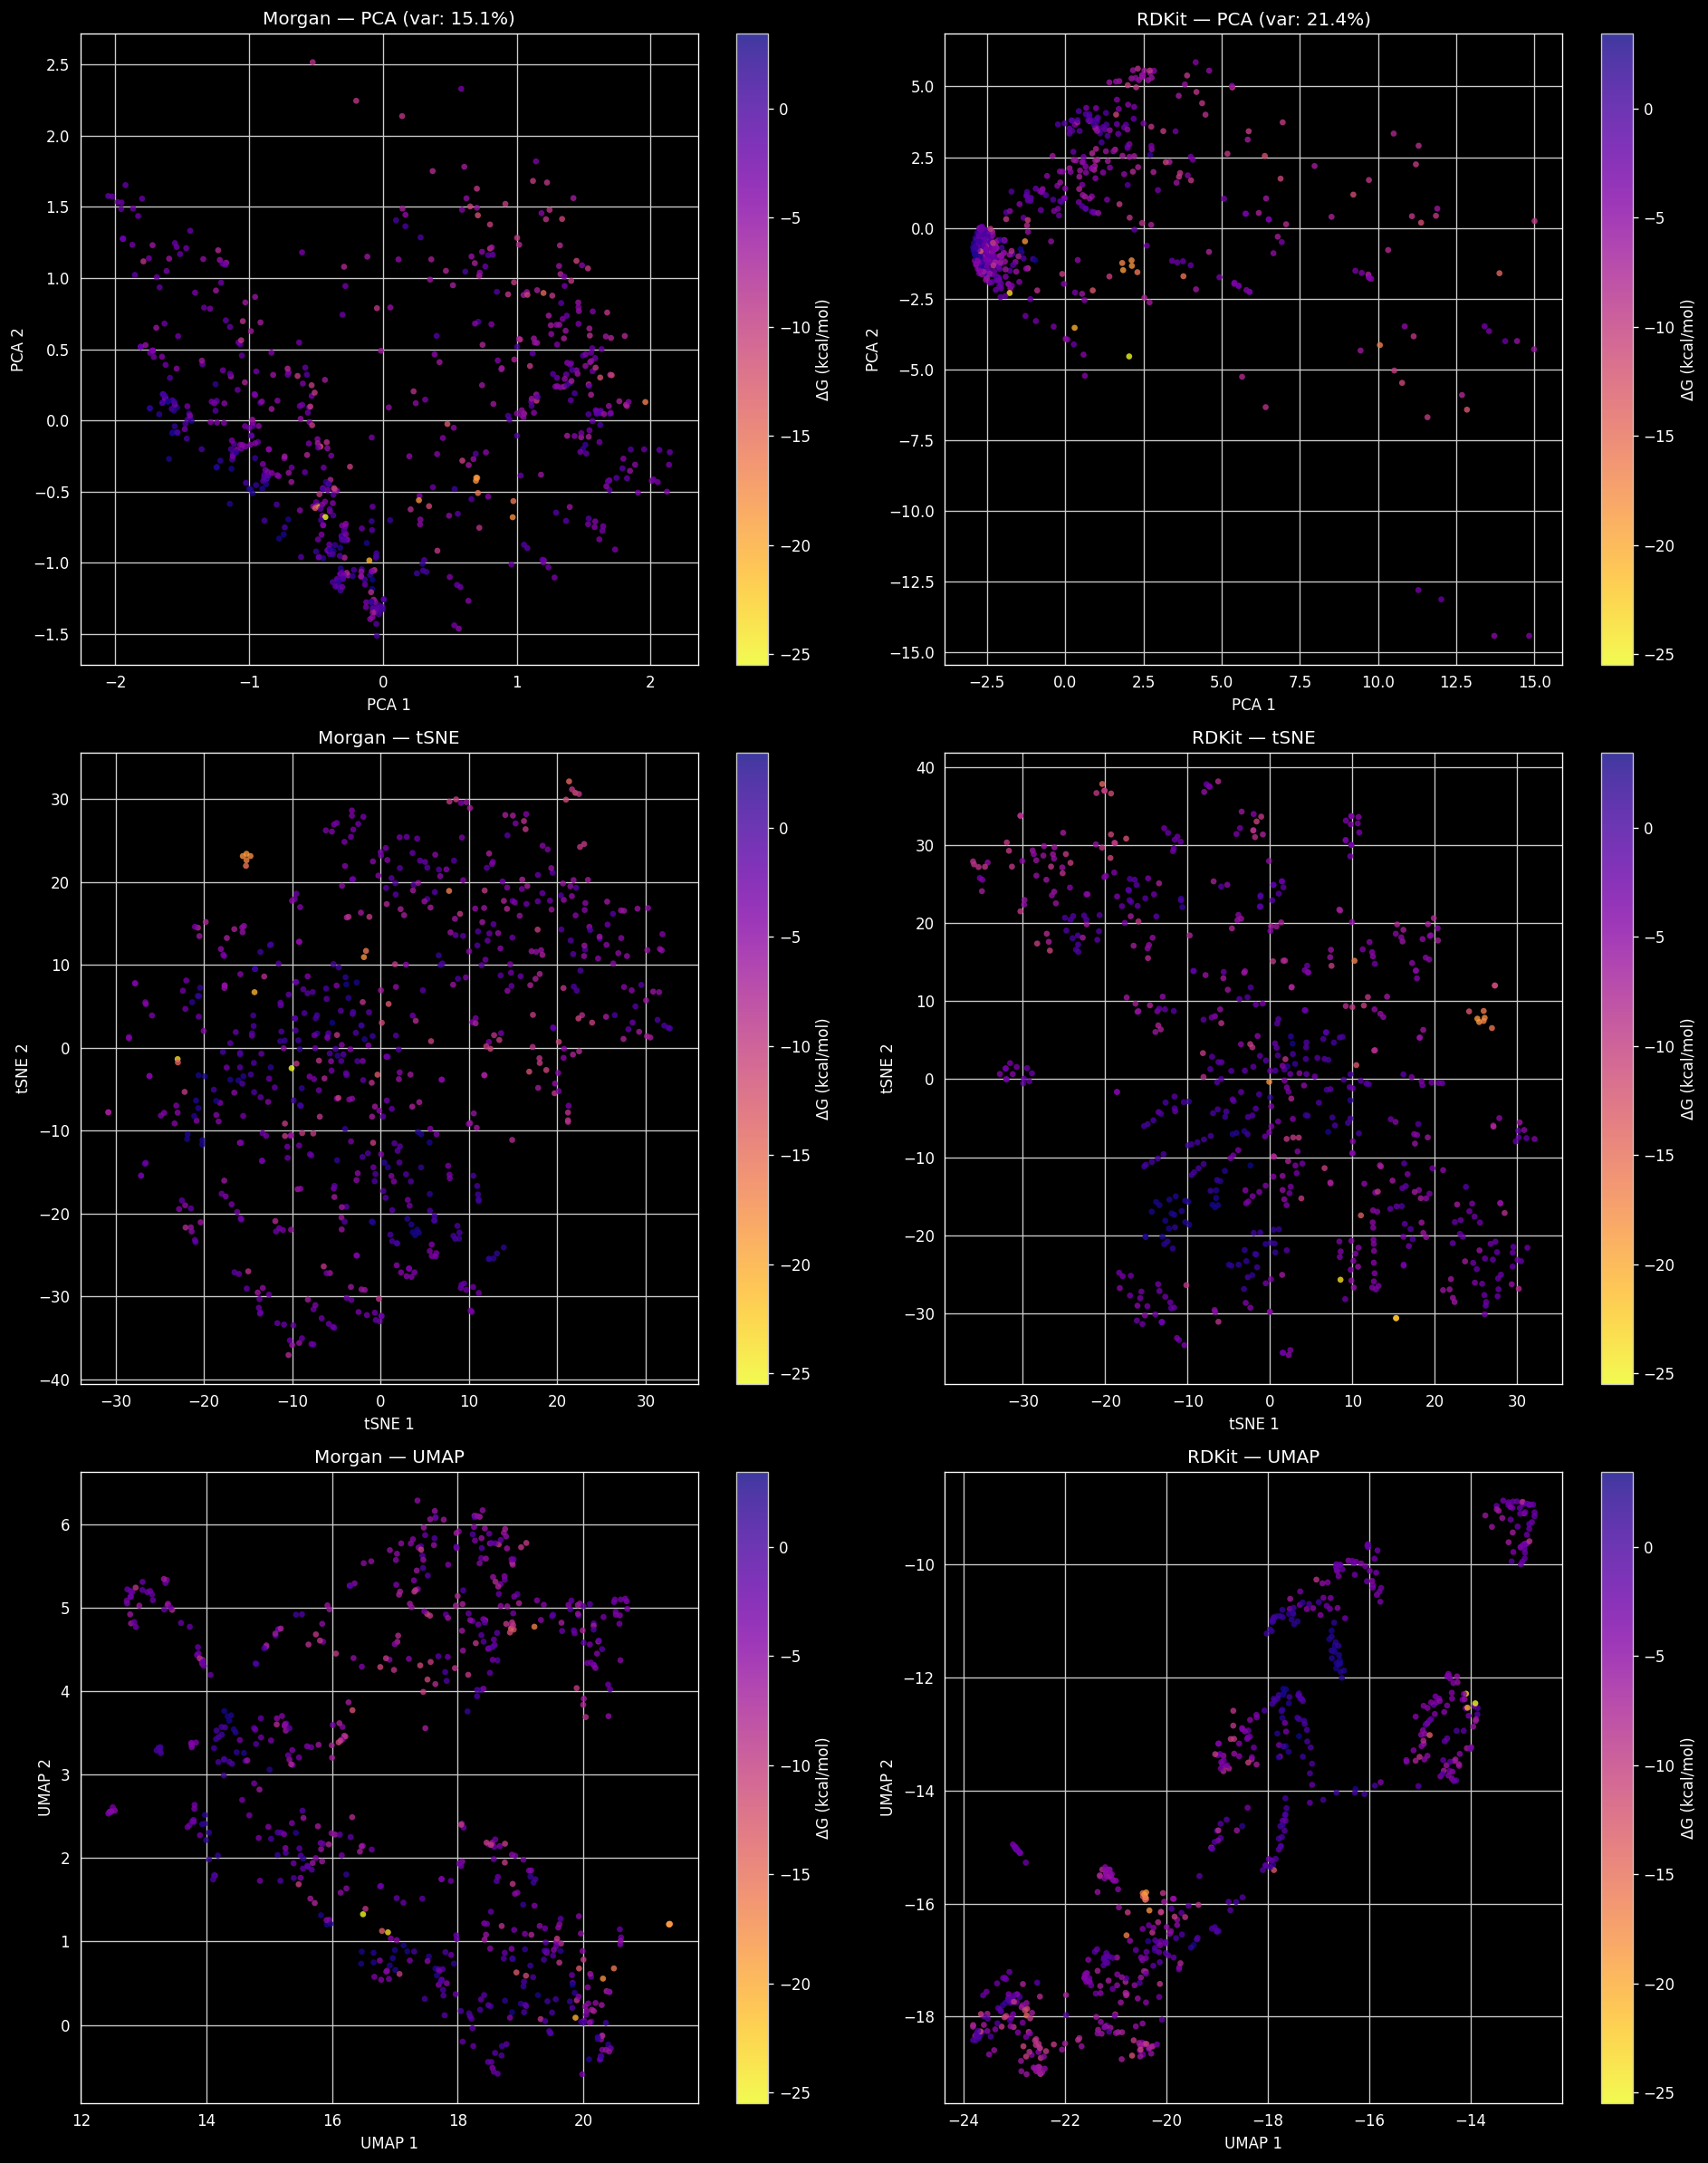

In [31]:
fig, axes = plt.subplots(3, 2, figsize=(16, 20), facecolor="black")
expt_vals = df["expt"].values
methods = ["PCA", "tSNE", "UMAP"]

for col, fp_name in enumerate(["Morgan", "RDKit"]):
    for row, method in enumerate(methods):
        emb = embeddings[f"{fp_name}_{method}"]
        sc = axes[row, col].scatter(emb[:, 0], emb[:, 1], c=expt_vals, cmap="plasma_r",
                                     s=16, alpha=0.8, edgecolors="none")
        var_str = f" (var: {embeddings[f'{fp_name}_PCA_var']:.1%})" if method == "PCA" else ""
        axes[row, col].set_title(f"{fp_name} — {method}{var_str}", color="white")
        axes[row, col].set_xlabel(f"{method} 1", color="white")
        axes[row, col].set_ylabel(f"{method} 2", color="white")
        plt.colorbar(sc, ax=axes[row, col], label="ΔG (kcal/mol)")

for ax in axes.flat:
    ax.set_facecolor("black")
    ax.tick_params(colors="white")
    for spine in ax.spines.values():
        spine.set_color("white")

for cb_ax in [a for a in fig.get_axes() if a not in axes.flat]:
    cb_ax.yaxis.label.set_color("white")
    cb_ax.tick_params(colors="white")
    plt.setp(cb_ax.yaxis.get_ticklabels(), color="white")

plt.tight_layout()
plt.show()

PCA captures almost nothing — the first two PCs explain only 9% (Morgan) and 3% (RDKit) of total variance. Expected for 2048-bit binary fingerprints. tSNE and UMAP both show clear structure, and ΔG changes smoothly across the maps. UMAP gives the tightest clusters.

## Clustering & Nearest Neighbor Analysis

In [32]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

# Cluster on t-SNE and UMAP embeddings with DBSCAN
# Scale embeddings first since DBSCAN eps is distance-sensitive
cluster_results = {}
for fp_name in ["Morgan", "RDKit"]:
    for method in ["tSNE", "UMAP"]:
        emb = embeddings[f"{fp_name}_{method}"]
        emb_scaled = StandardScaler().fit_transform(emb)

        # Sweep eps to find one that doesn't put everything in one cluster or noise
        best_score, best_eps, best_labels = -1, None, None
        for eps in np.arange(0.15, 0.8, 0.05):
            db = DBSCAN(eps=eps, min_samples=10)
            labels = db.fit_predict(emb_scaled)
            n_clusters = len(set(labels) - {-1})
            noise_frac = (labels == -1).mean()
            if n_clusters >= 2 and noise_frac < 0.5:
                score = silhouette_score(emb_scaled[labels != -1], labels[labels != -1])
                if score > best_score:
                    best_score, best_eps, best_labels = score, eps, labels

        key = f"{fp_name}_{method}"
        cluster_results[key] = best_labels
        n_clusters = len(set(best_labels) - {-1})
        noise_frac = (best_labels == -1).mean()
        print(f"{key}: eps={best_eps:.2f}, {n_clusters} clusters, "
              f"{noise_frac:.1%} noise, silhouette={best_score:.3f}")

Morgan_tSNE: eps=0.20, 15 clusters, 31.5% noise, silhouette=0.274
Morgan_UMAP: eps=0.15, 14 clusters, 22.3% noise, silhouette=0.482
RDKit_tSNE: eps=0.20, 17 clusters, 17.0% noise, silhouette=0.334
RDKit_UMAP: eps=0.15, 9 clusters, 2.6% noise, silhouette=0.547


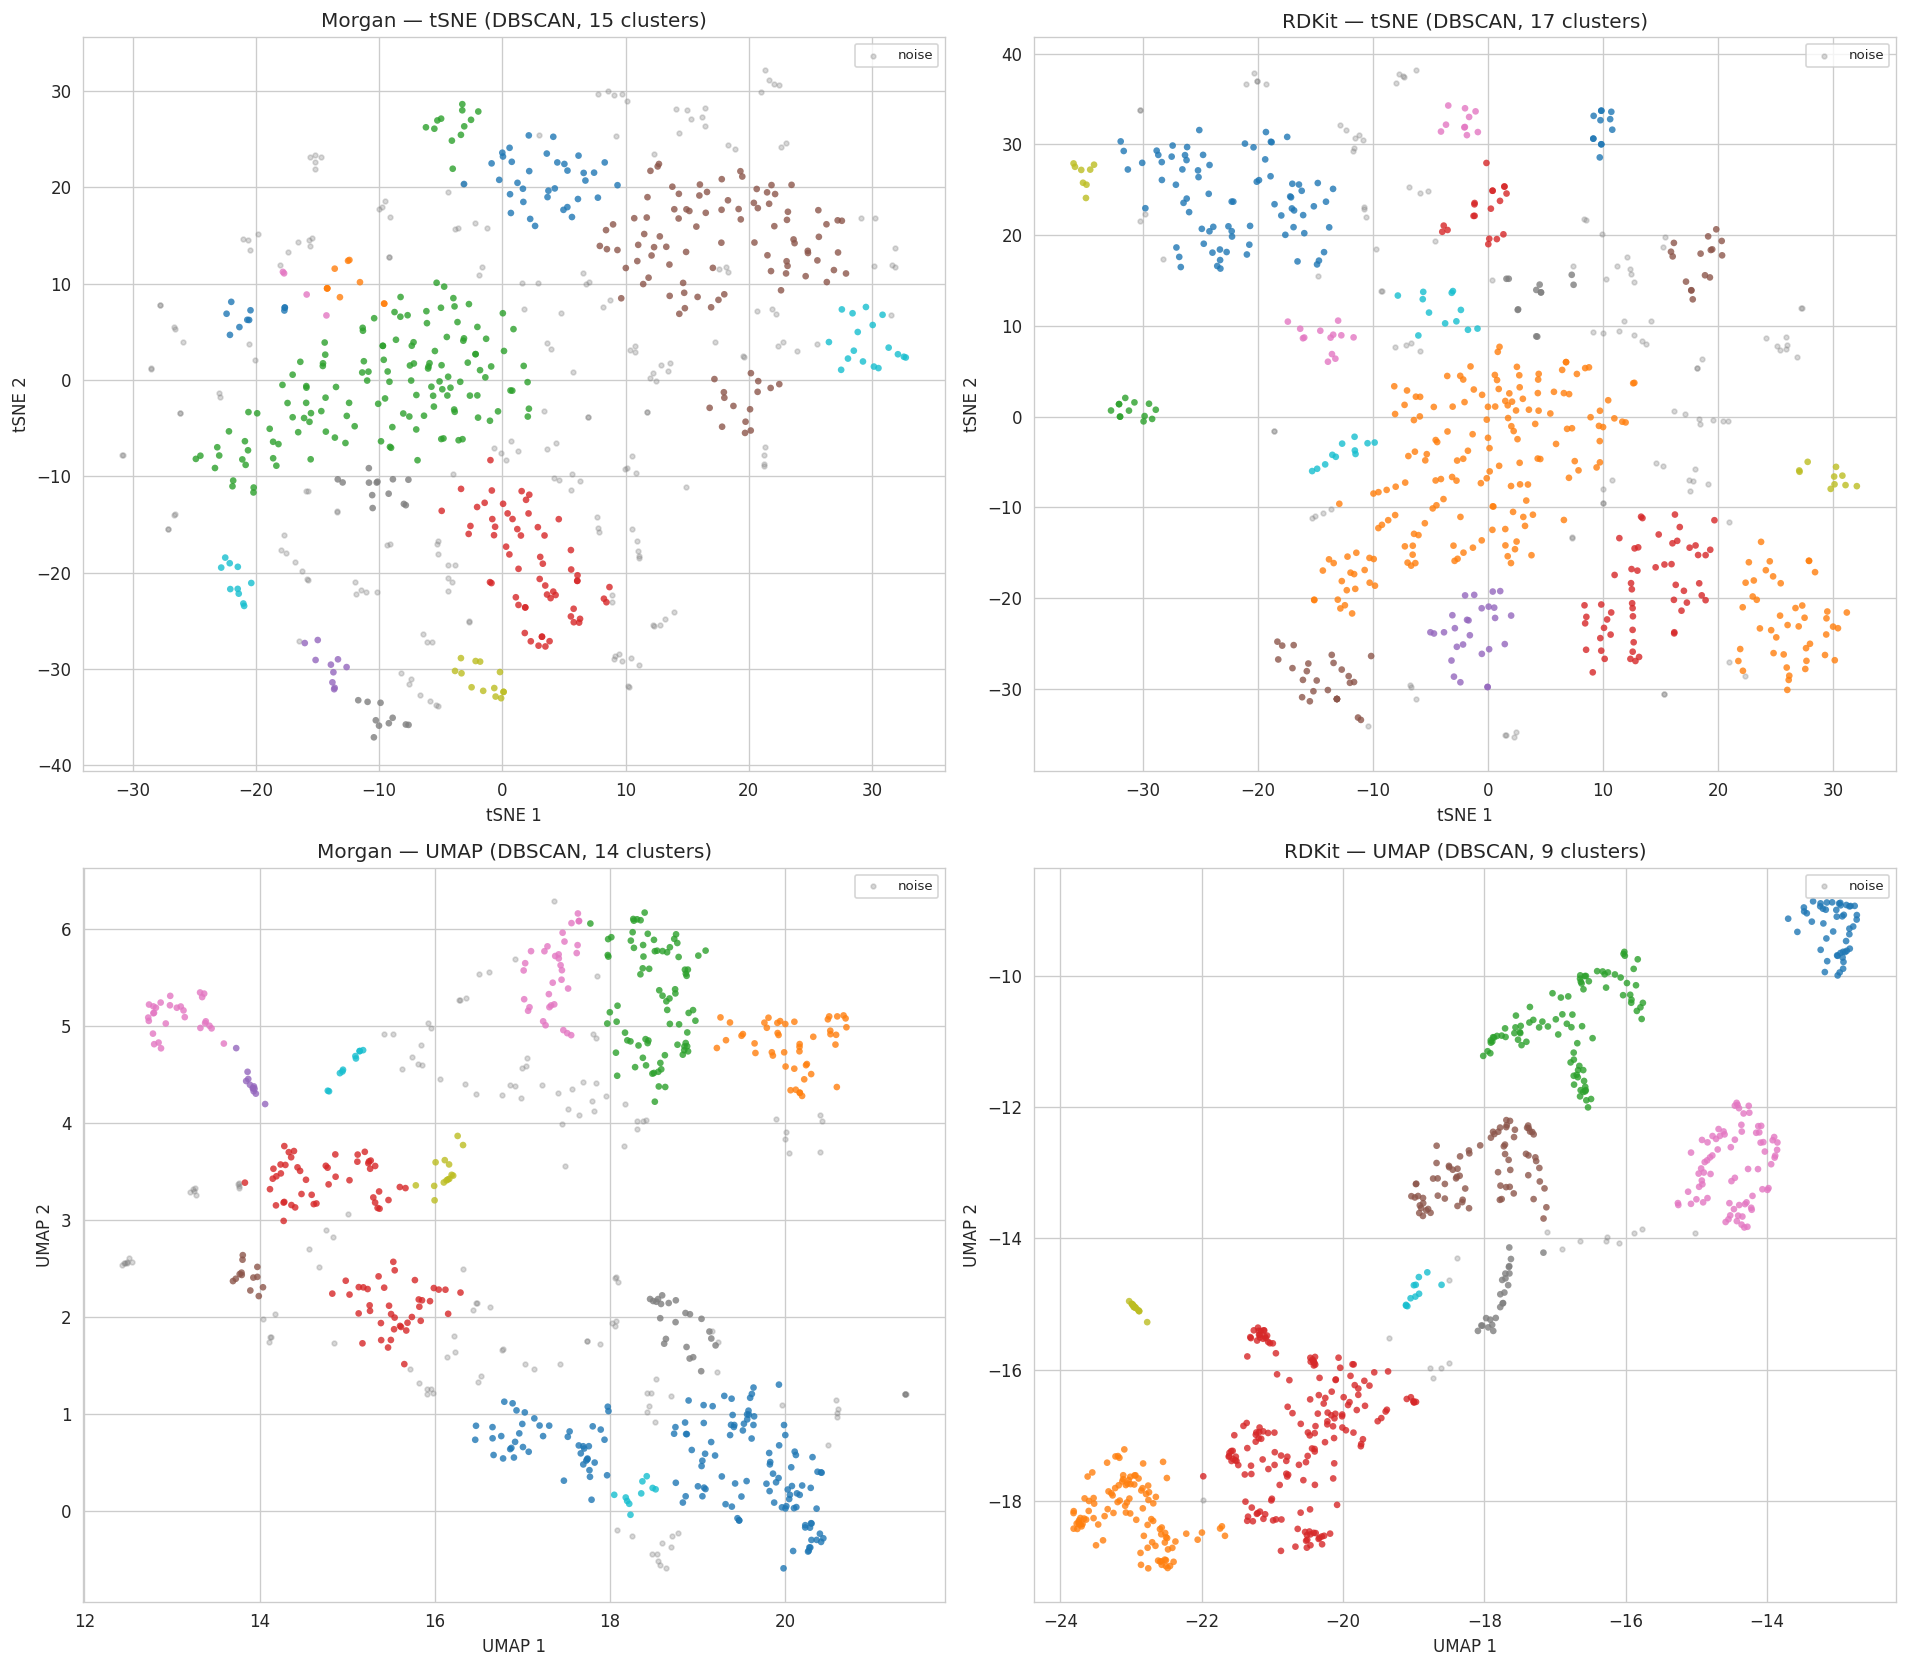

In [33]:
# Visualize DBSCAN clusters on their respective embeddings
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

for col, fp_name in enumerate(["Morgan", "RDKit"]):
    for row, method in enumerate(["tSNE", "UMAP"]):
        key = f"{fp_name}_{method}"
        emb = embeddings[key]
        labels = cluster_results[key]
        n_clusters = len(set(labels) - {-1})

        ax = axes[row, col]
        noise_mask = labels == -1
        ax.scatter(emb[noise_mask, 0], emb[noise_mask, 1], c="grey",
                   s=8, alpha=0.3, label="noise")
        if (~noise_mask).any():
            sc = ax.scatter(emb[~noise_mask, 0], emb[~noise_mask, 1],
                           c=labels[~noise_mask], cmap="tab10",
                           s=16, alpha=0.8, edgecolors="none")
        ax.set_title(f"{fp_name} — {method} (DBSCAN, {n_clusters} clusters)")
        ax.set_xlabel(f"{method} 1"); ax.set_ylabel(f"{method} 2")
        ax.legend(loc="upper right", fontsize=8)

plt.tight_layout()
plt.show()

In [34]:
# Pick best clustering result by silhouette (reusing scores from the sweep above)
best_key = max(cluster_results.keys(),
               key=lambda k: silhouette_score(
                   StandardScaler().fit_transform(embeddings[k])[cluster_results[k] != -1],
                   cluster_results[k][cluster_results[k] != -1])
               if len(set(cluster_results[k][cluster_results[k] != -1])) >= 2 else -1)

# Recompute once for display
best_mask = cluster_results[best_key] != -1
best_sil = silhouette_score(
    StandardScaler().fit_transform(embeddings[best_key])[best_mask],
    cluster_results[best_key][best_mask])
print(f"Best clustering: {best_key} (silhouette={best_sil:.3f})")

df["cluster"] = cluster_results[best_key]

df_clustered = df[df["cluster"] != -1]
cluster_summary = df_clustered.groupby("cluster").agg(
    n=("expt", "size"),
    expt_mean=("expt", "mean"),
    expt_median=("expt", "median"),
    expt_std=("expt", "std"),
    MolWt_mean=("MolWt", "mean"),
    LogP_mean=("LogP", "mean"),
    TPSA_mean=("TPSA", "mean"),
    HBD_mean=("HBD", "mean"),
    HBA_mean=("HBA", "mean"),
    AromaticRings_mean=("AromaticRings", "mean"),
).round(2).sort_values("expt_median")
print(f"\nNoise points: {(df['cluster'] == -1).sum()}")
print(cluster_summary)

print("\nDominant functional groups per cluster (sorted by median ΔG):")
for c in cluster_summary.index:
    grps = df_groups[df_groups.index.isin(df[df["cluster"] == c].index)]["groups"]
    top = grps.value_counts().head(3)
    print(f"\n  Cluster {c} (n={cluster_summary.loc[c, 'n']}, "
          f"median ΔG={cluster_summary.loc[c, 'expt_median']}):")
    for g, cnt in top.items():
        print(f"    {g}: {cnt}")

Best clustering: RDKit_UMAP (silhouette=0.547)

Noise points: 17
           n  expt_mean  expt_median  expt_std  MolWt_mean  LogP_mean  \
cluster                                                                 
1        106      -5.19        -5.30      3.58      157.44       2.33   
3        179      -5.17        -4.72      3.90      155.54       2.03   
5         77      -5.13        -4.42      4.20      107.09       0.68   
4         77      -2.33        -3.09      3.59      113.13       1.61   
7         14      -3.14        -3.01      0.86      321.52       6.53   
0         48      -3.67        -2.66      1.92      122.81       1.09   
2         89      -1.03        -2.15      2.92      117.15       2.30   
8         11      -3.42        -1.46      3.31      144.24       2.05   
6         24      -1.23        -0.64      2.66      129.93       2.20   

         TPSA_mean  HBD_mean  HBA_mean  AromaticRings_mean  
cluster                                                     
1        

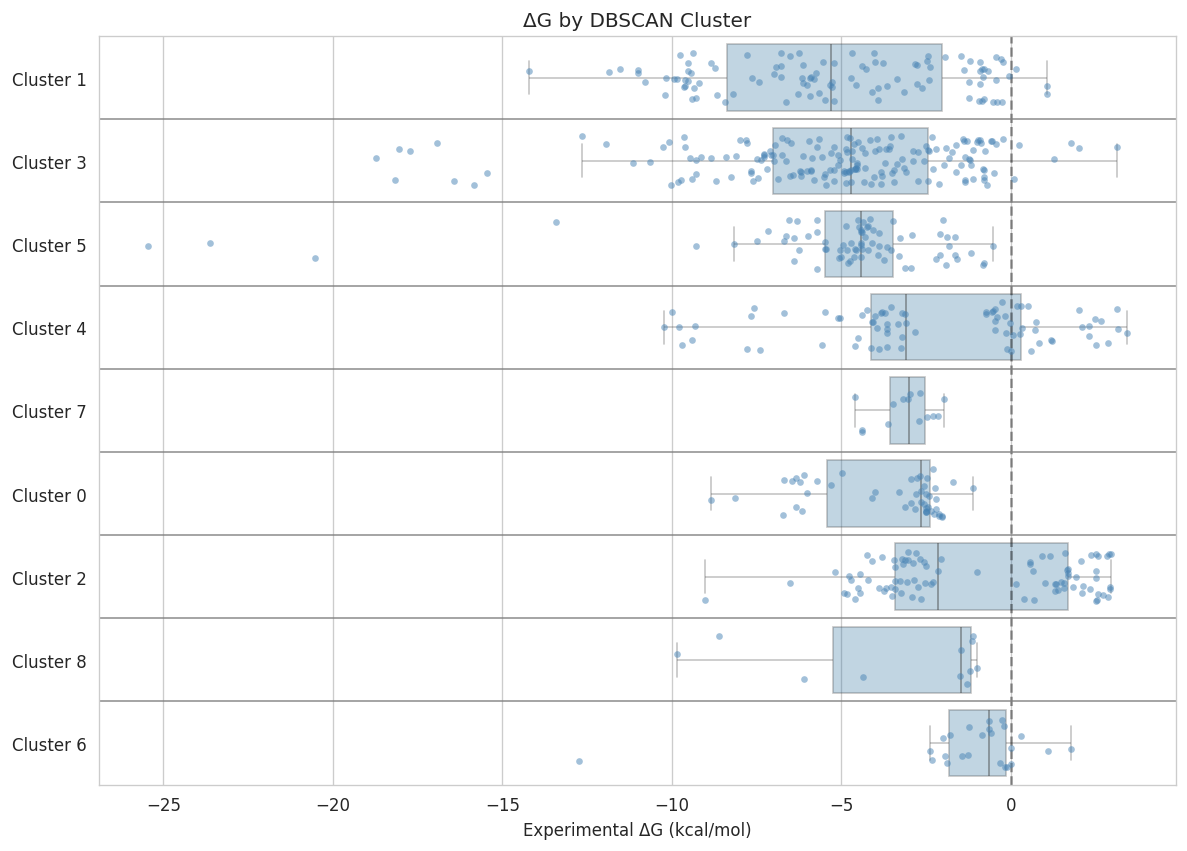

In [35]:
# ΔG distribution per cluster (excluding noise)
df_clustered = df[df["cluster"] != -1].copy()
df_clustered["cluster_label"] = df_clustered["cluster"].apply(lambda c: f"Cluster {c}")
order = df_clustered.groupby("cluster")["expt"].median().sort_values().index

fig, ax = plt.subplots(figsize=(10, max(5, len(order) * 0.8)))
sns.boxplot(data=df_clustered, y="cluster_label", x="expt",
            order=[f"Cluster {c}" for c in order], ax=ax,
            showfliers=False, boxprops=dict(alpha=0.3), whiskerprops=dict(alpha=0.3),
            medianprops=dict(alpha=0.5), capprops=dict(alpha=0.3))
sns.stripplot(data=df_clustered, y="cluster_label", x="expt",
              order=[f"Cluster {c}" for c in order], ax=ax,
              size=4, alpha=0.5, jitter=0.3, color="steelblue")
ax.axvline(0, color="black", linestyle="--", alpha=0.4)
for i in range(len(order) - 1):
    ax.axhline(i + 0.5, color="grey", linewidth=1.2, alpha=0.7)
ax.set_xlabel("Experimental ΔG (kcal/mol)")
ax.set_ylabel("")
ax.set_title("ΔG by DBSCAN Cluster")
plt.tight_layout()
plt.show()

In [36]:
import warnings
from sklearn.exceptions import DataConversionWarning
from sklearn.neighbors import NearestNeighbors
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.neighbors import KNeighborsRegressor

# jaccard on int arrays triggers an annoying but harmless dtype warning
warnings.filterwarnings("ignore", category=DataConversionWarning)

# LOO-CV for honest KNN evaluation
results = {}
for fp_name, fps in [("Morgan", morgan_fps), ("RDKit", rdkit_fps)]:
    for k in [3, 5, 10, 20]:
        knn = KNeighborsRegressor(n_neighbors=k, metric="jaccard")
        preds = cross_val_predict(knn, fps, df["expt"].values, cv=LeaveOneOut())
        mae = np.abs(preds - df["expt"].values).mean()
        r = np.corrcoef(preds, df["expt"].values)[0, 1]
        results[(fp_name, k)] = {"MAE": mae, "r": r}

results_df = pd.DataFrame(results).T
results_df.index.names = ["FP", "k"]
results_df.round(3)

MAE      r
FP     k               
Morgan 3   1.556  0.814
       5   1.628  0.803
       10  1.828  0.783
       20  1.927  0.761
RDKit  3   1.164  0.870
       5   1.276  0.867
       10  1.418  0.838
       20  1.635  0.787

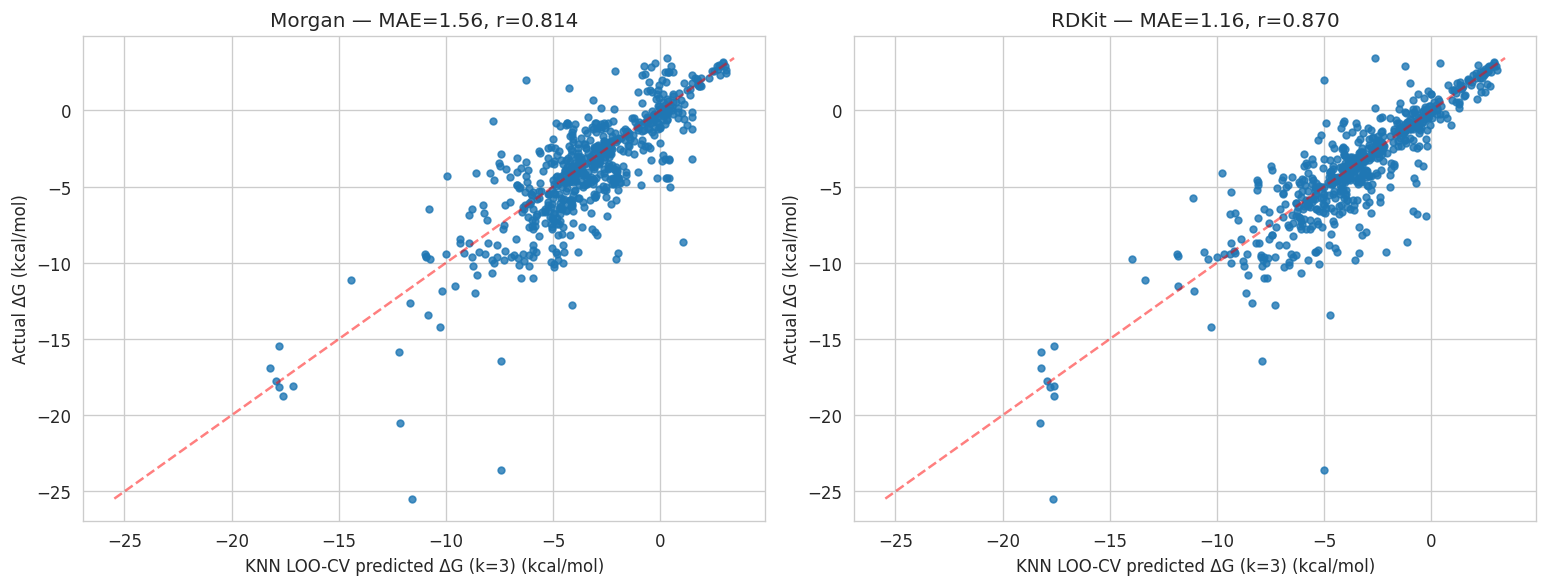

In [37]:
# Scatter: KNN LOO-CV predicted ΔG vs actual (best k per FP by MAE)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (fp_name, fps) in zip(axes, [("Morgan", morgan_fps), ("RDKit", rdkit_fps)]):
    best_k = min([(k, v["MAE"]) for (fp, k), v in results.items() if fp == fp_name], key=lambda x: x[1])[0]

    knn = KNeighborsRegressor(n_neighbors=best_k, metric="jaccard")
    preds = cross_val_predict(knn, fps, df["expt"].values, cv=LeaveOneOut())
    mae = np.abs(preds - df["expt"].values).mean()
    r = np.corrcoef(preds, df["expt"].values)[0, 1]

    ax.scatter(preds, df["expt"].values, s=16, alpha=0.8)
    lims = [min(preds.min(), df["expt"].min()), max(preds.max(), df["expt"].max())]
    ax.plot(lims, lims, "r--", alpha=0.5)
    ax.set_xlabel(f"KNN LOO-CV predicted ΔG (k={best_k}) (kcal/mol)")
    ax.set_ylabel("Actual ΔG (kcal/mol)")
    ax.set_title(f"{fp_name} — MAE={mae:.2f}, r={r:.3f}")

plt.tight_layout()
plt.show()

DBSCAN on UMAP embeddings worked well — **RDKit_UMAP** gave 9 clusters that actually make chemical sense (silhouette=0.55, only 2.6% noise):

- Clusters split along chemistry: polar aromatics (phenols), substituted aromatics (heterocycles, aryl chlorides), polar aliphatics (alcohols, ethers), esters, unsaturated/carbonyl, sulfur-containing, and alkyl halides
- Median ΔG ranges from -5.3 (polar aromatics) to -0.6 (alkyl chlorides) — so cluster identity lines up with how strongly they solvate
- Cluster 7 is interesting: 14 polyhalogenated aromatics with very high MW (321) and LogP (6.5) but zero TPSA — structurally distinct, moderately hydrophilic despite being nonpolar (van der Waals solvation?)

**KNN (LOO-CV):** RDKit FPs with k=3 give MAE=1.16 kcal/mol, r=0.87 — structurally similar molecules do have similar ΔG. RDKit FPs consistently beat Morgan here, probably because topological paths capture more of the small-molecule diversity than circular environments do.

## Summary

**Q1**: What cheap 2D info predicts ΔG? **Q2**: Where do expensive simulations fail?

In [39]:
# Q1: What cheap 2D info predicts ΔG?
print("=== Descriptor correlations with expt ΔG ===")
desc_corr = df[desc_cols].corrwith(df["expt"]).sort_values()
for name, val in desc_corr.items():
    print(f"  {name:>16s}: {val:+.3f}")

print(f"\n=== KNN LOO-CV (best k per fingerprint) ===")
for fp_name in ["Morgan", "RDKit"]:
    best_k, best_mae, best_r = None, 999, 0
    for (fp, k), v in results.items():
        if fp == fp_name and v["MAE"] < best_mae:
            best_k, best_mae, best_r = k, v["MAE"], v["r"]
    print(f"  {fp_name:>6s} (k={best_k}): MAE={best_mae:.2f} kcal/mol, r={best_r:.3f}")

print(f"\n=== Functional groups — most/least hydrophilic (n ≥ 10) ===")
big_q1 = group_stats[group_stats["count"] >= 10].sort_values("median")
print(f"  Most hydrophilic:  {big_q1.index[0]} (median={big_q1.iloc[0]['median']:.1f}, n={big_q1.iloc[0]['count']:.0f})")
print(f"  Least hydrophilic: {big_q1.index[-1]} (median={big_q1.iloc[-1]['median']:.1f}, n={big_q1.iloc[-1]['count']:.0f})")

# Q2: Where do simulations fail?
print(f"\n=== Simulation accuracy ===")
print(f"  calc vs expt: r={df['calc'].corr(df['expt']):.3f}")
print(f"  Mean residual (calc - expt): {df['residual'].mean():+.2f} kcal/mol")
print(f"  Std residual: {df['residual'].std():.2f} kcal/mol")
print(f"  |residual| > 4 kcal/mol: {(df['residual'].abs() > 4).sum()} molecules")

print(f"\n=== Worst predictions ===")
worst5 = df.nlargest(5, "residual", keep="first")[["nickname", "expt", "calc", "residual"]].copy()
worst5["nickname"] = worst5["nickname"].str.strip()
worst5_neg = df.nsmallest(5, "residual", keep="first")[["nickname", "expt", "calc", "residual"]].copy()
worst5_neg["nickname"] = worst5_neg["nickname"].str.strip()
print("  Overpredicted (calc >> expt):")
for _, r in worst5.iterrows():
    print(f"    {r['nickname']:>25s}  expt={r['expt']:+6.2f}  calc={r['calc']:+7.2f}  err={r['residual']:+6.2f}")
print("  Underpredicted (calc << expt):")
for _, r in worst5_neg.iterrows():
    print(f"    {r['nickname']:>25s}  expt={r['expt']:+6.2f}  calc={r['calc']:+7.2f}  err={r['residual']:+6.2f}")

print(f"\n=== Worst 10 vs rest (descriptor means) ===")
worst10_idx = df["residual"].abs().nlargest(10).index
for col in ["MolWt", "TPSA", "HBD", "HBA"]:
    w = df.loc[worst10_idx, col].mean()
    r = df.loc[~df.index.isin(worst10_idx), col].mean()
    print(f"  {col:>5s}: worst10={w:.1f}, rest={r:.1f}")

print(f"\n=== Simulation error by functional group (n ≥ 10) ===")
big_q2 = resid_stats[resid_stats["count"] >= 10].sort_values("median", ascending=False)
print("  Hardest (highest median |error|):")
for g, row in big_q2.head(5).iterrows():
    print(f"    {g:>40s}  median={row['median']:.2f}, n={row['count']:.0f}")
print("  Easiest (lowest median |error|):")
for g, row in big_q2.tail(5).iterrows():
    print(f"    {g:>40s}  median={row['median']:.2f}, n={row['count']:.0f}")

=== Descriptor correlations with expt ΔG ===
              TPSA: -0.736
               HBD: -0.690
               HBA: -0.597
    NumHeteroatoms: -0.408
        HeavyAtoms: -0.350
     AromaticRings: -0.323
         RingCount: -0.310
             MolWt: -0.235
          RotBonds: -0.006
      FractionCSP3: +0.306
              LogP: +0.344

=== KNN LOO-CV (best k per fingerprint) ===
  Morgan (k=3): MAE=1.56 kcal/mol, r=0.814
   RDKit (k=3): MAE=1.16 kcal/mol, r=0.870

=== Functional groups — most/least hydrophilic (n ≥ 10) ===
  Most hydrophilic:  oxo(het)arene (median=-16.1, n=12)
  Least hydrophilic: alkyl bromide (median=-0.4, n=17)

=== Simulation accuracy ===
  calc vs expt: r=0.933
  Mean residual (calc - expt): +0.32 kcal/mol
  Std residual: 1.51 kcal/mol
  |residual| > 4 kcal/mol: 16 molecules

=== Worst predictions ===
  Overpredicted (calc >> expt):
                    d-glucose  expt=-25.47  calc= -18.09  err= +7.38
                       xylose  expt=-20.52  calc= -14.15  